## About Dataset

Lending Club

Lending Club is a peer-to-peer Lending company based in the US. They match people looking to invest money with people looking to borrow money. When investors invest their money through Lending Club, this money is passed onto borrowers, and when borrowers pay their loans back, the capital plus the interest passes on back to the investors. It is a win for everybody as they can get typically lower loan rates and higher investor returns.

The Lending Club dataset contains complete loan data for all loans issued through the 2007-2015, including the current loan status (Current, Late, Fully Paid, etc.) and latest payment information. Features (aka variables) include credit scores, number of finance inquiries, address including zip codes and state, and collections among others. Collections indicates whether the customer has missed one or more payments and the team is trying to recover their money. The file is a matrix of about 890 thousand observations and 75 variables.


Grade | Risk Level | Typical Interest Rate
---|---:|---:
A | Lowest risk | ~6–8%
B | Low risk | ~9–12%
C | Moderate risk | ~13–16%
D | Medium-high risk | ~17–20%
E | High risk | ~21–24%
F | Very high risk | ~25–28%
G | Highest risk | ~29%+

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
pd.options.display.max_rows = None

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Path to dataset files:", path)

100%|██████████| 339M/339M [00:01<00:00, 239MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adarshsng/lending-club-loan-data-csv/versions/1


In [4]:
import os
print(os.listdir(path))

['LCDataDictionary.xlsx', 'loan.csv']


In [5]:
df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = 75000)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## EDA

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,75000.0,15861.884333,10162.640008,1000.00,8000.0000,13500.000,21000.0000,4.000000e+04
funded_amnt,75000.0,15861.884333,10162.640008,1000.00,8000.0000,13500.000,21000.0000,4.000000e+04
funded_amnt_inv,75000.0,15858.938000,10164.992407,725.00,8000.0000,13500.000,21000.0000,4.000000e+04
int_rate,75000.0,13.046117,4.956675,6.00,8.8100,11.800,16.1400,3.094000e+01
installment,75000.0,460.123855,285.298178,30.64,250.1100,380.540,620.8275,1.618240e+03
annual_inc,75000.0,83208.190837,109313.472978,0.00,48000.0000,69000.000,100000.0000,9.757200e+06
url,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check missing values

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
id,75000
member_id,75000
hardship_start_date,75000
deferral_term,75000
hardship_status,75000
hardship_loan_status,75000
orig_projected_additional_accrued_interest,75000
hardship_payoff_balance_amount,75000
hardship_last_payment_amount,75000
settlement_status,75000


In [8]:
drop_missing_columns = list(df.columns[df.isnull().sum() > 50000])
drop_missing_columns

['id',
 'member_id',
 'url',
 'desc',
 'mths_since_last_record',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'deferral_term',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_length',
 'hardship_dpd',
 'hardship_loan_status',
 'orig_projected_additional_accrued_interest',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',


In [9]:
len(drop_missing_columns)

42

In [10]:
df.drop(columns = drop_missing_columns, inplace=True)

In [11]:
numerical = list(df.dtypes[df.dtypes != 'object'].index)
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

#### Check variable variance

In [12]:
df[numerical].apply(lambda x: x.std()).sort_values()

,0
acc_now_delinq,0.000000
policy_code,0.000000
collection_recovery_fee,0.000000
recoveries,0.000000
num_tl_120dpd_2m,0.000000
tax_liens,0.000000
num_tl_30dpd,0.000000
chargeoff_within_12_mths,0.093909
collections_12_mths_ex_med,0.148694
pub_rec_bankruptcies,0.333121


In [13]:
df['chargeoff_within_12_mths'].value_counts()

,count
chargeoff_within_12_mths,
0,74528
1,439
2,25
3,5
4,2
7,1


In [14]:
df['policy_code'].value_counts()

,count
policy_code,
1,75000


In [15]:
df['num_tl_120dpd_2m'].value_counts()

,count
num_tl_120dpd_2m,
0.0,73192


In [16]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # tune this

numeric_cols = df.select_dtypes(include='number').columns

selector.fit(df[numeric_cols])

# See which columns are kept
kept = numeric_cols[selector.get_support()]
dropped = numeric_cols[~selector.get_support()]
print("Dropped:", dropped.tolist())

Dropped: ['recoveries', 'collection_recovery_fee', 'policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens']


In [17]:
len(dropped)

8

In [18]:
for col in categorical:
    print(col, df[col].nunique())
    if df[col].nunique() < 10:
        print(df[col].value_counts())
    print()

term 2
term
36 months    51386
60 months    23614
Name: count, dtype: int64

grade 7
grade
A    21566
B    21191
C    18432
D     9962
E     3749
F       74
G       26
Name: count, dtype: int64

sub_grade 34

emp_title 28063

emp_length 11

home_ownership 4
home_ownership
MORTGAGE    37092
RENT        29442
OWN          8268
ANY           198
Name: count, dtype: int64

verification_status 3
verification_status
Not Verified       35138
Source Verified    28576
Verified           11286
Name: count, dtype: int64

issue_d 2
issue_d
Dec-2018    40134
Nov-2018    34866
Name: count, dtype: int64

loan_status 6
loan_status
Current               72740
Fully Paid             1724
In Grace Period         260
Late (31-120 days)      182
Late (16-30 days)        82
Charged Off              12
Name: count, dtype: int64

pymnt_plan 1
pymnt_plan
n    75000
Name: count, dtype: int64

purpose 12

title 12

zip_code 871

addr_state 50

earliest_cr_line 629

initial_list_status 2
initial_list_status
w    

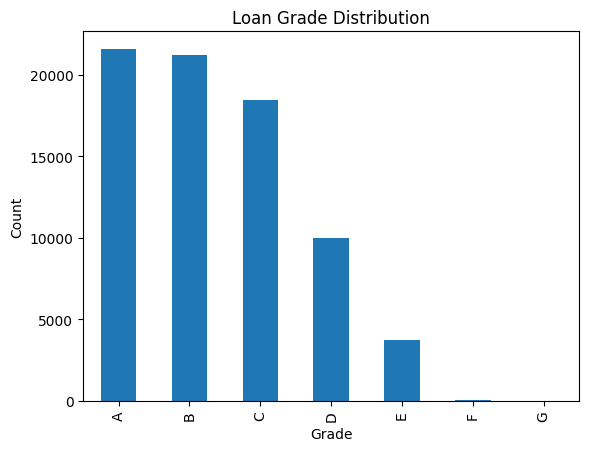

In [19]:
df['grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

### Bivariate charts

/tmp/ipykernel_19918/866535275.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


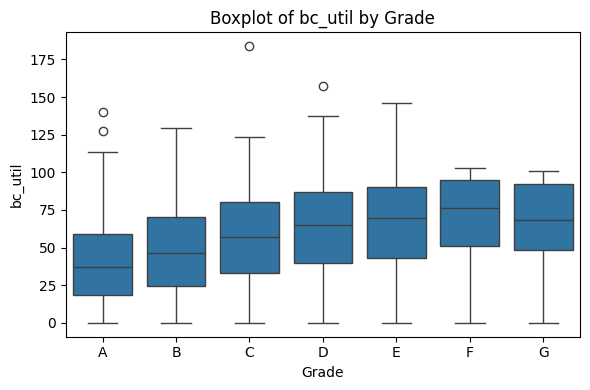

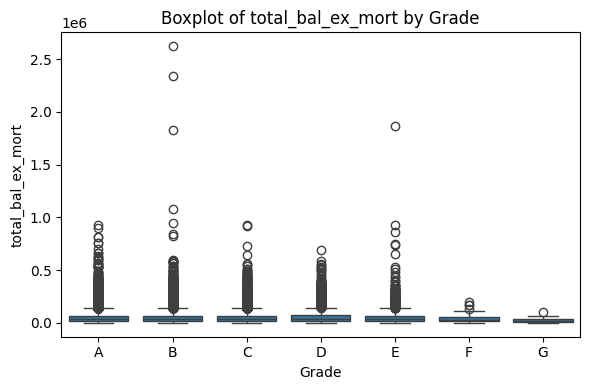

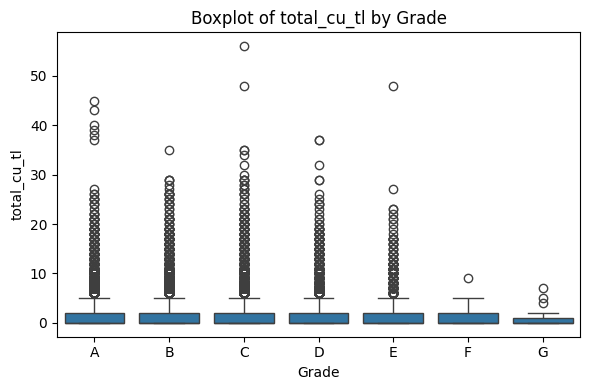

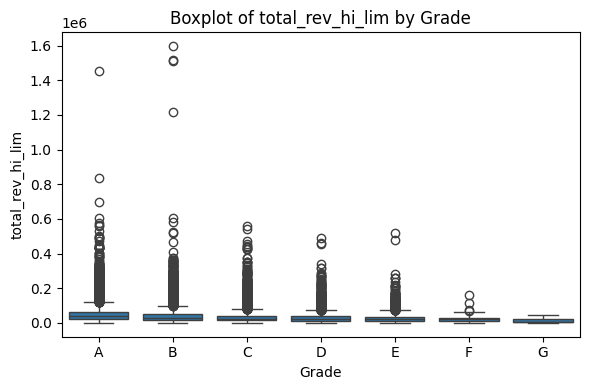

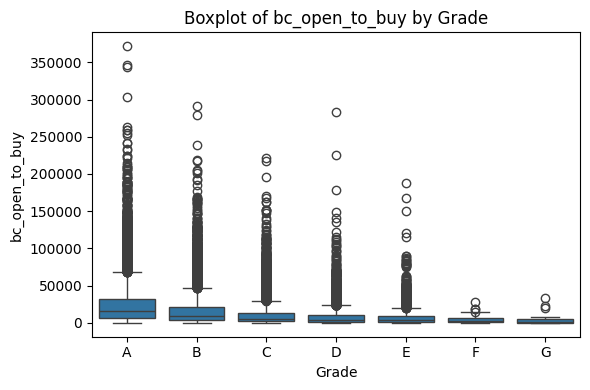

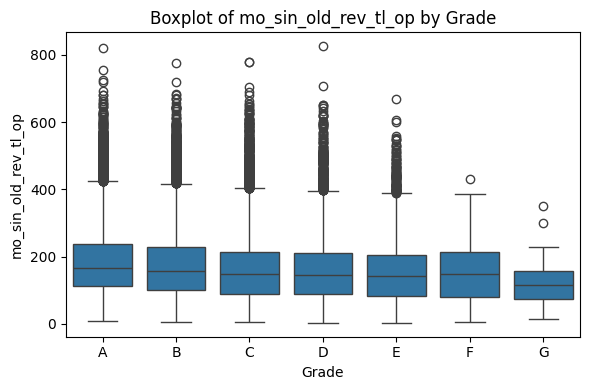

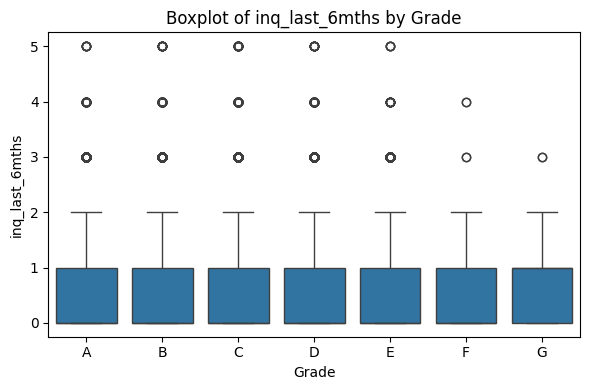

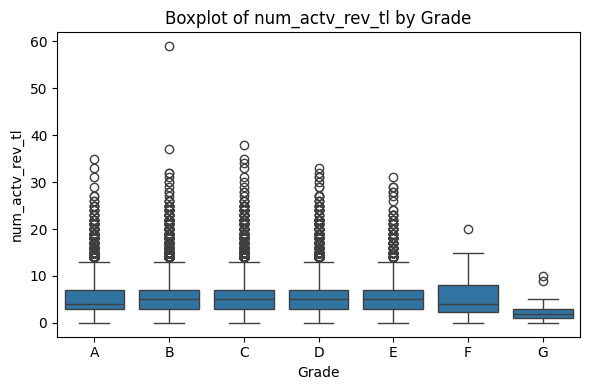

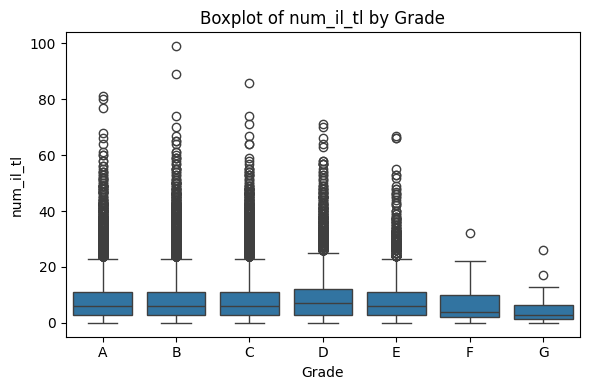

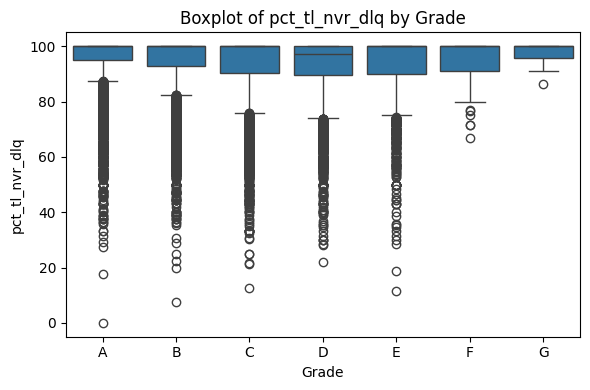

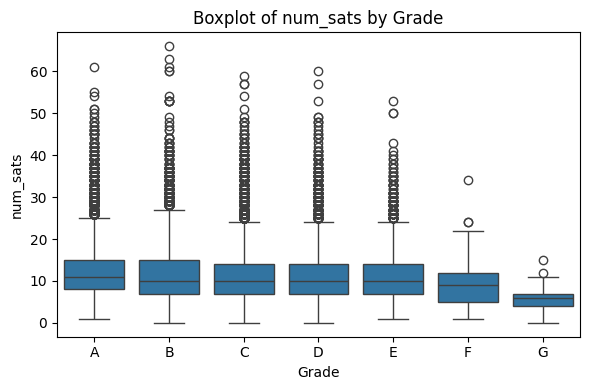

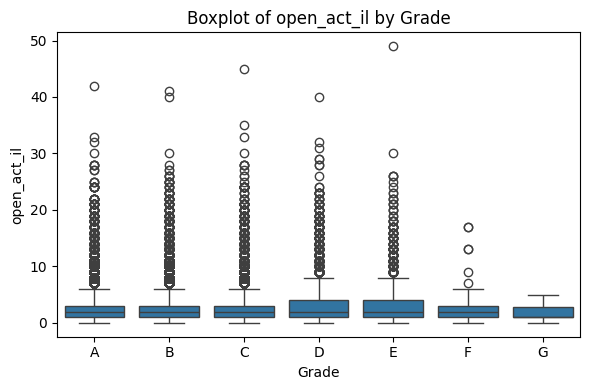

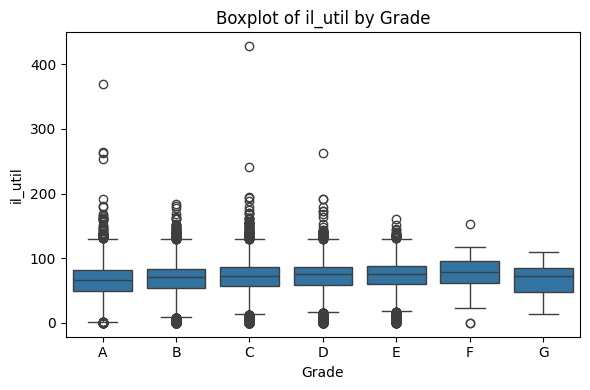

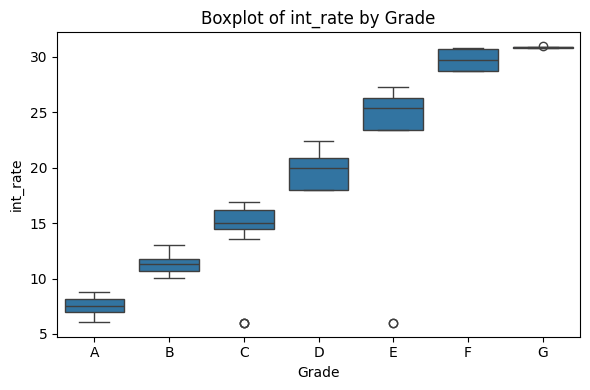

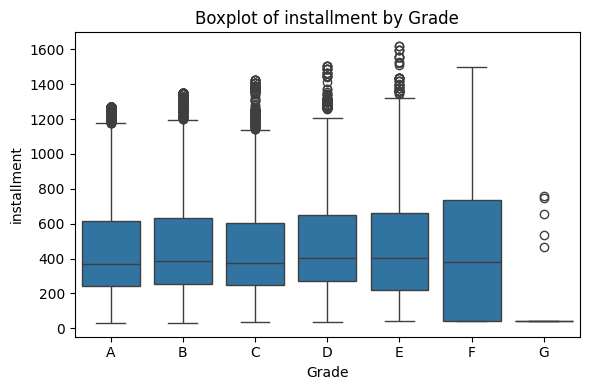

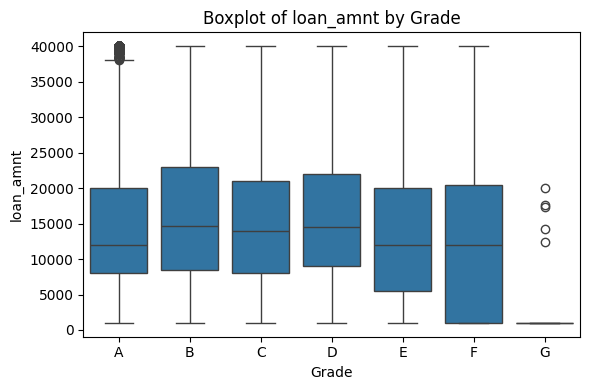

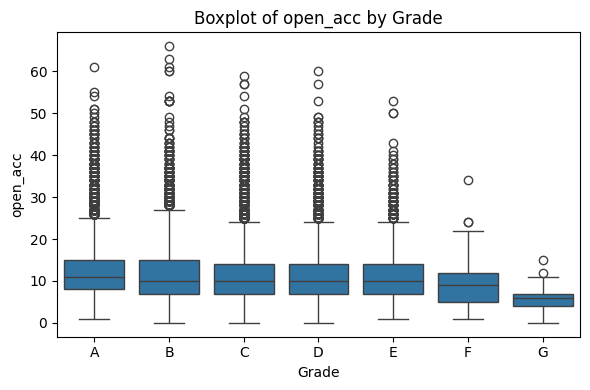

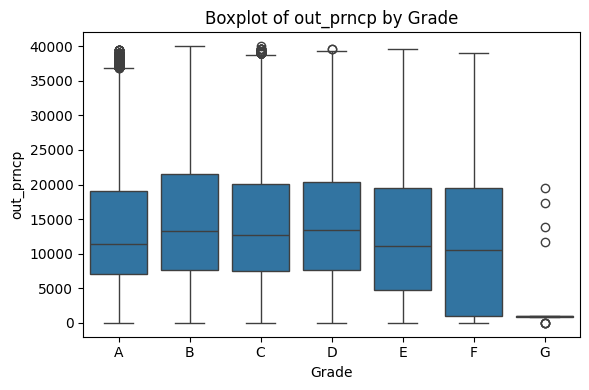

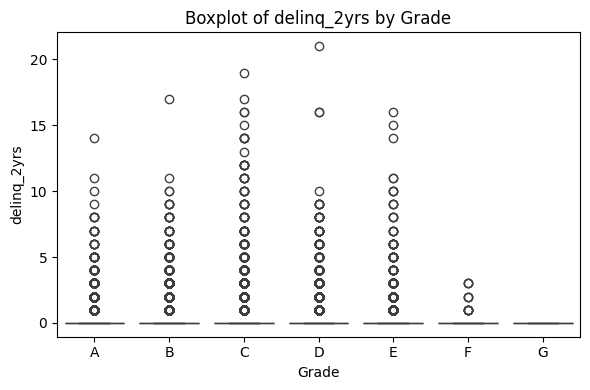

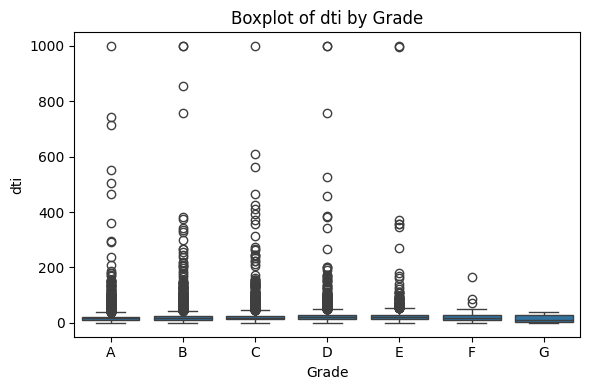

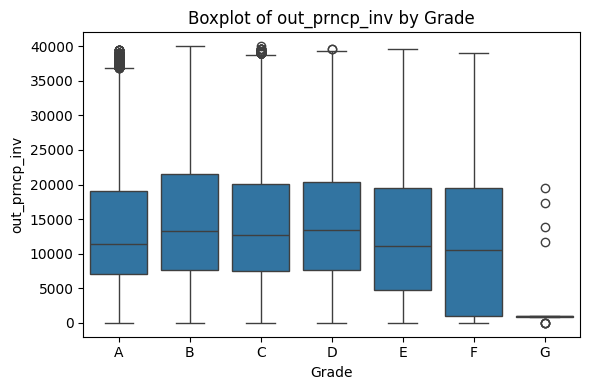

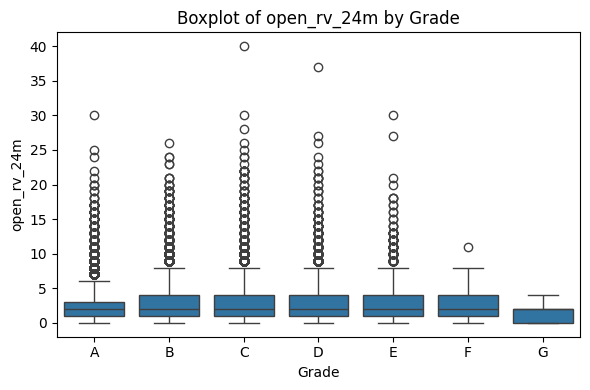

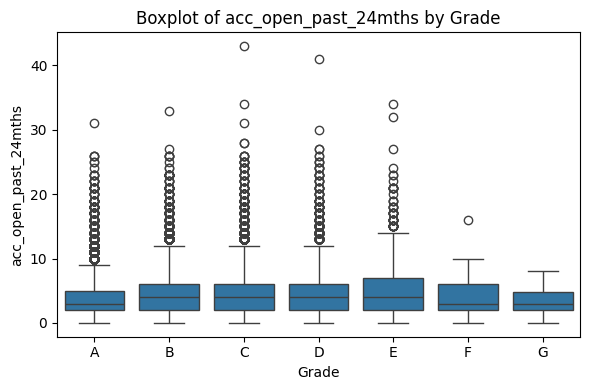

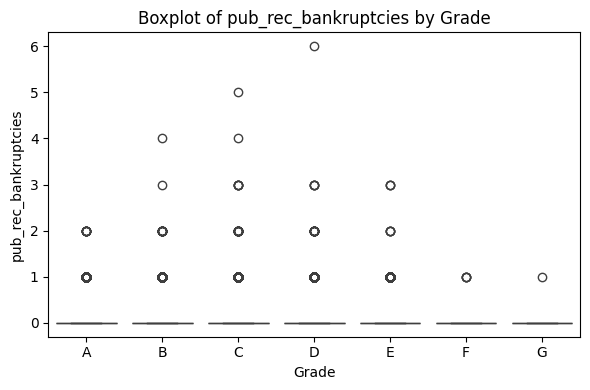

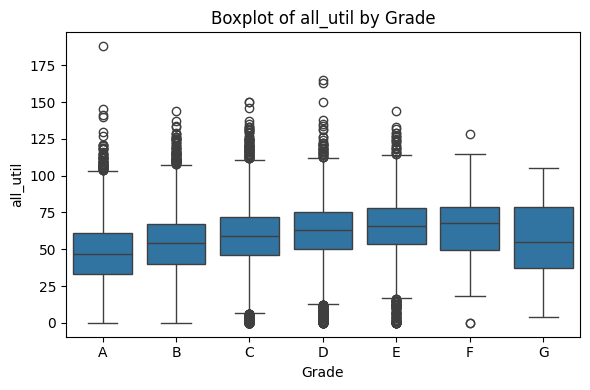

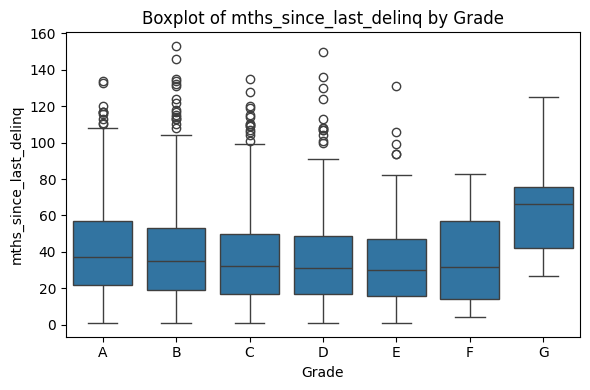

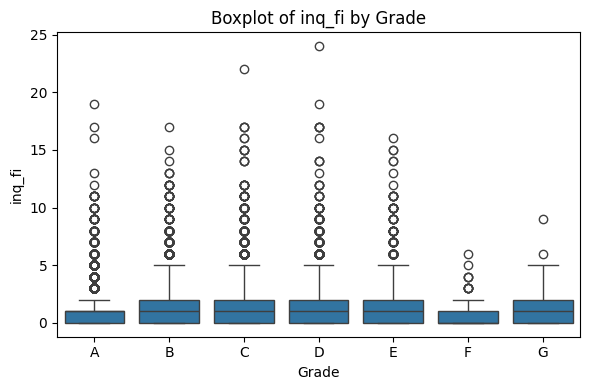

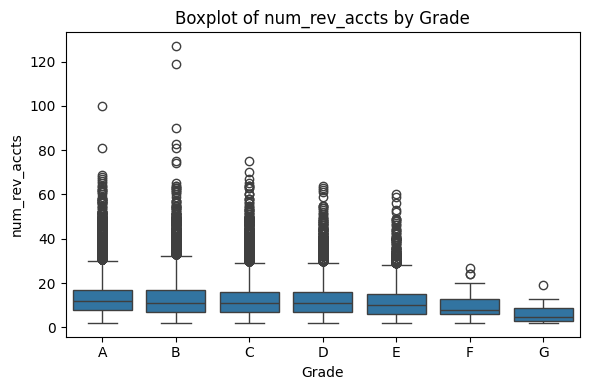

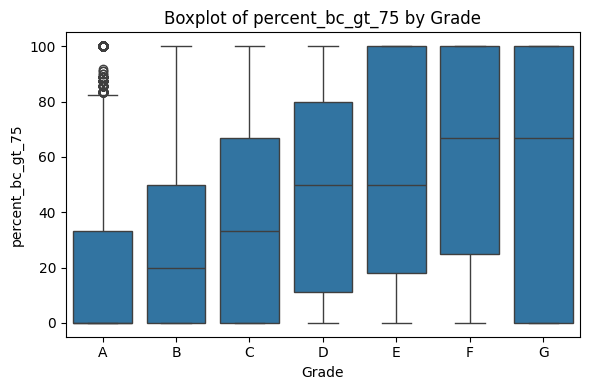

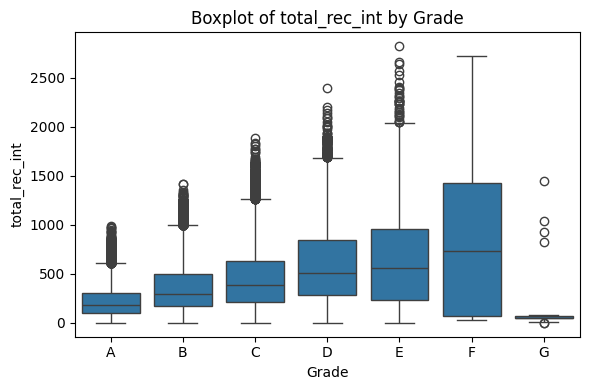

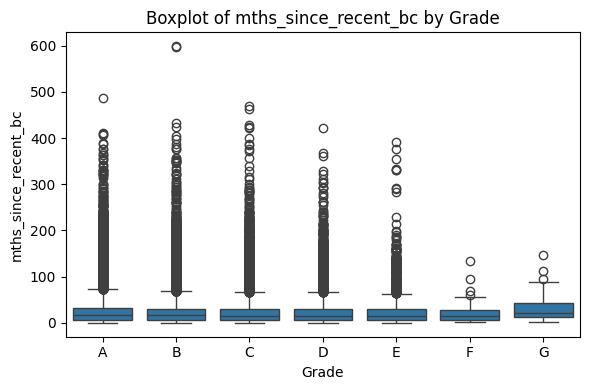

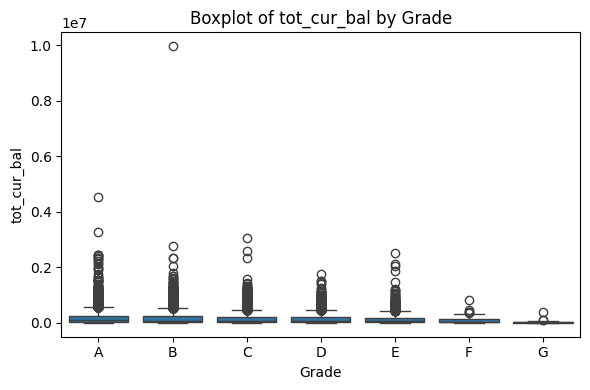

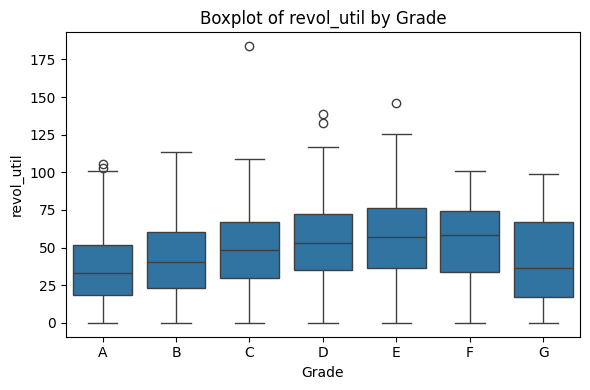

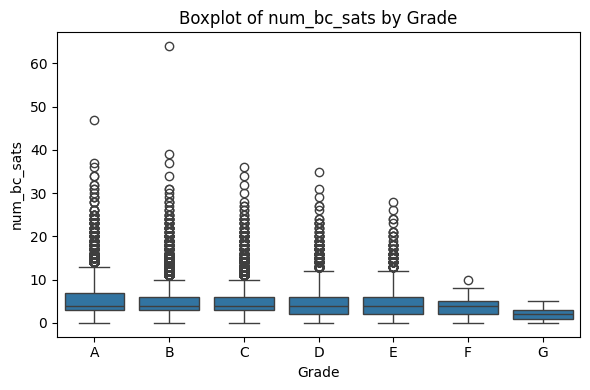

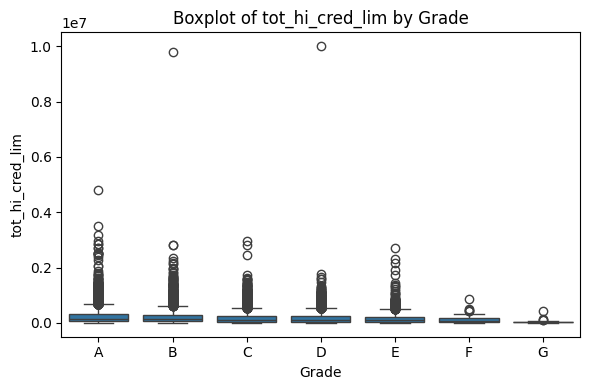

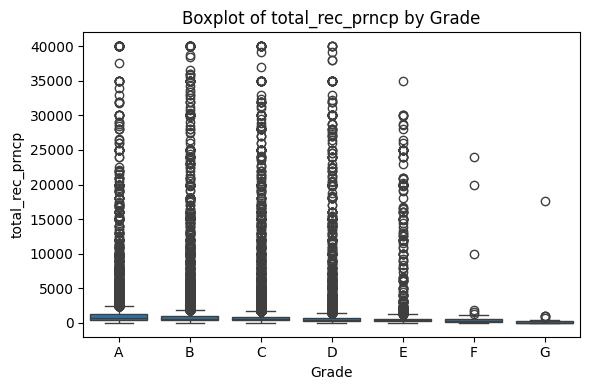

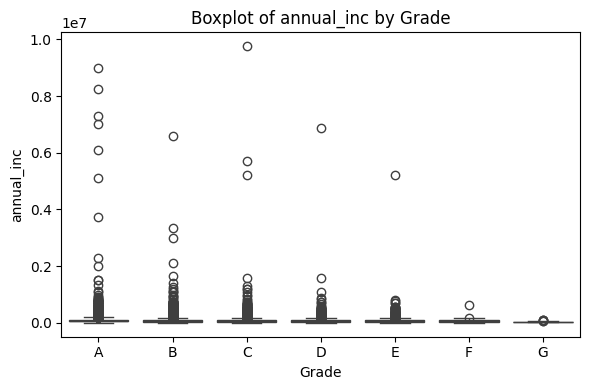

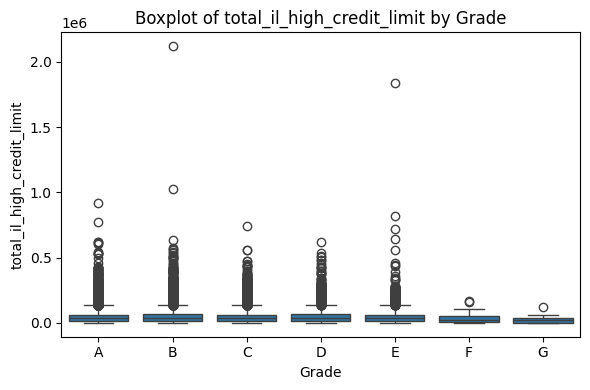

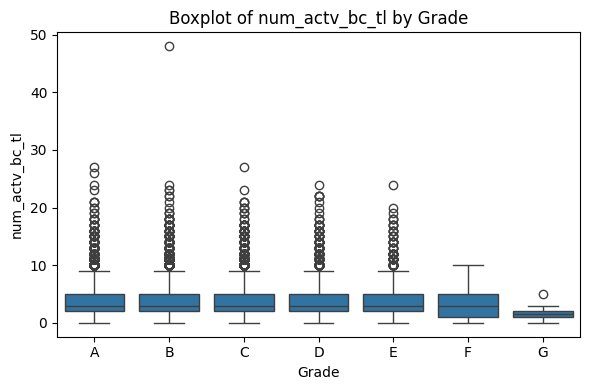

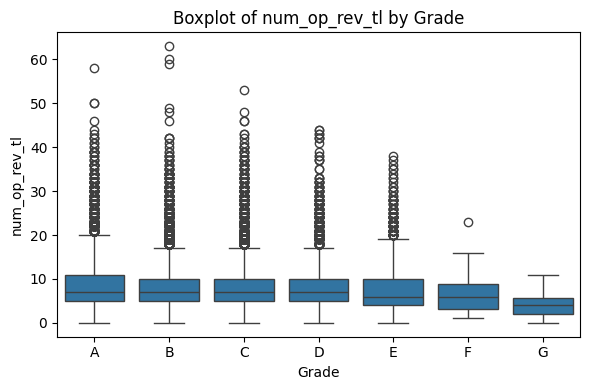

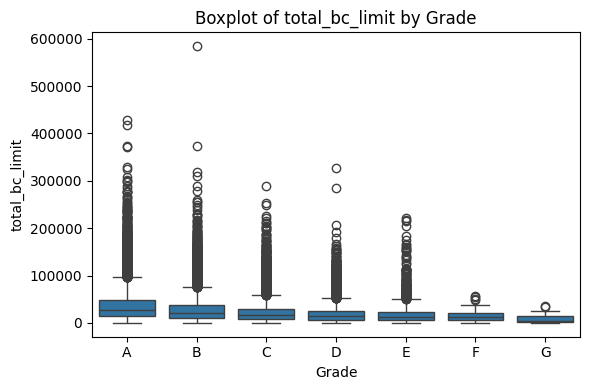

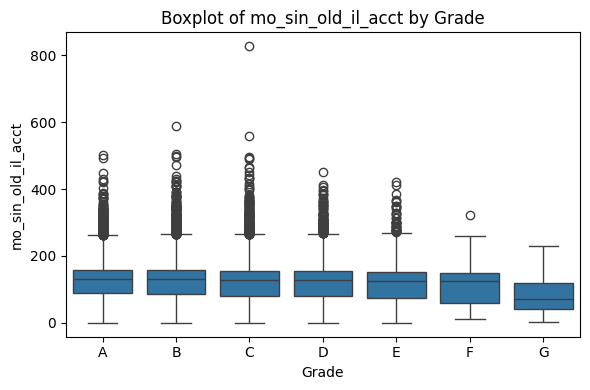

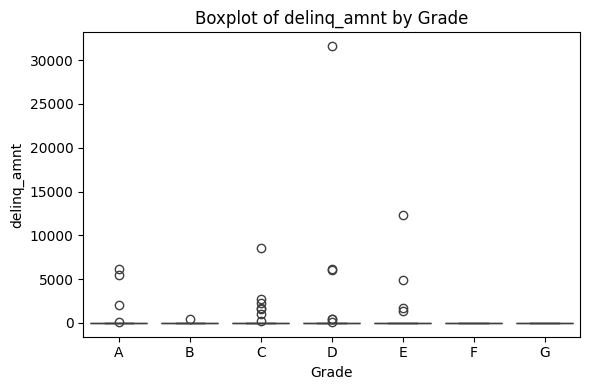

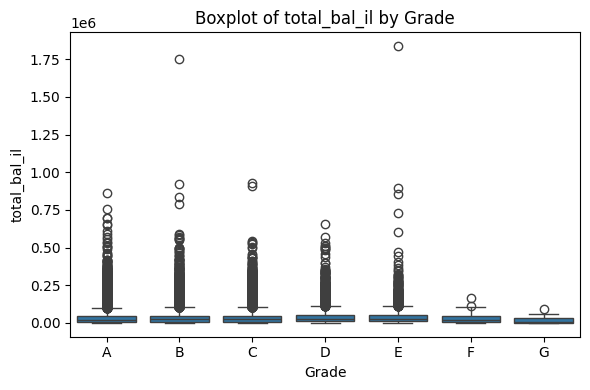

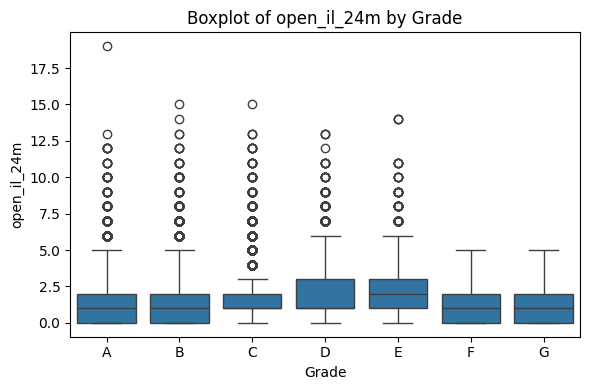

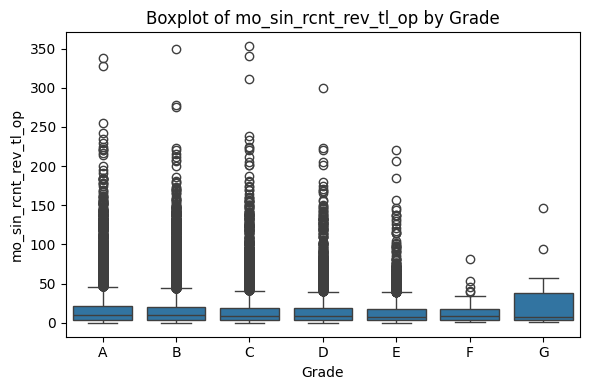

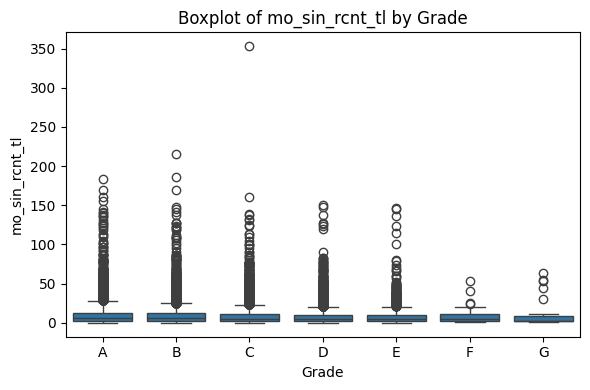

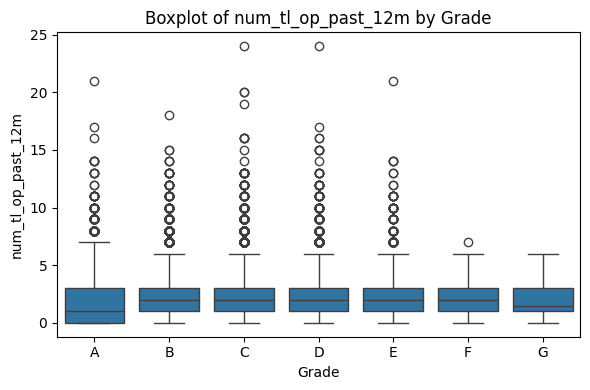

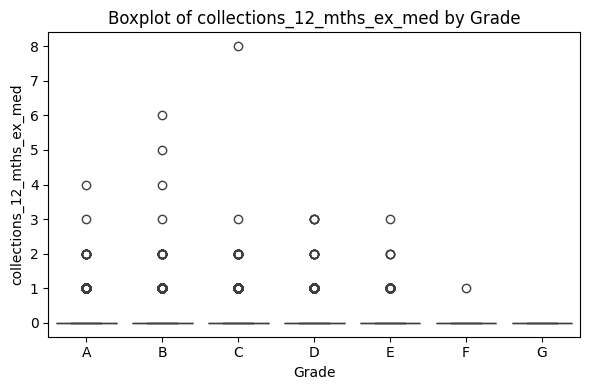

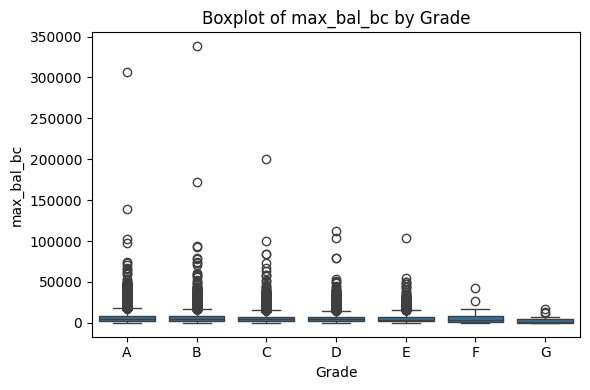

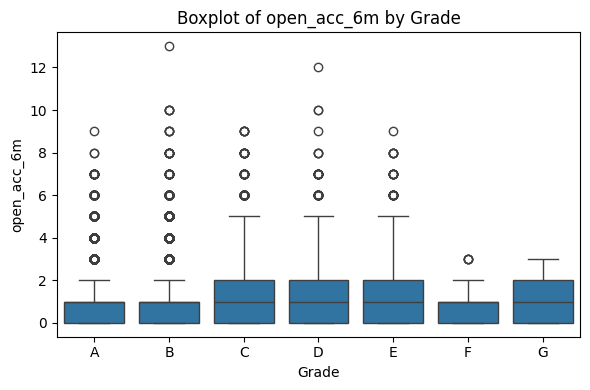

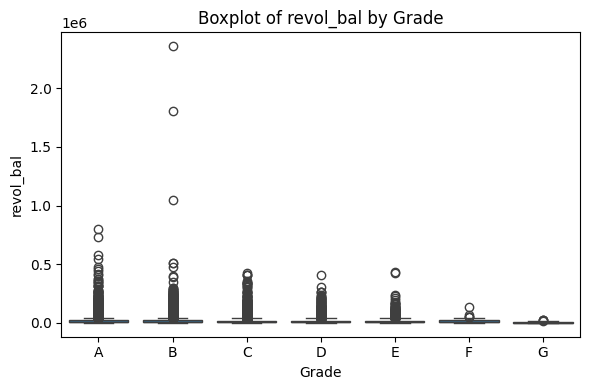

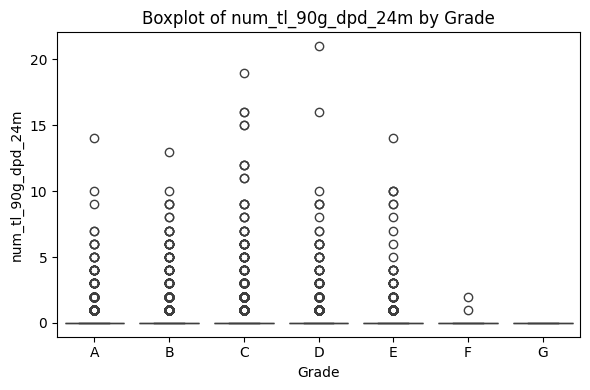

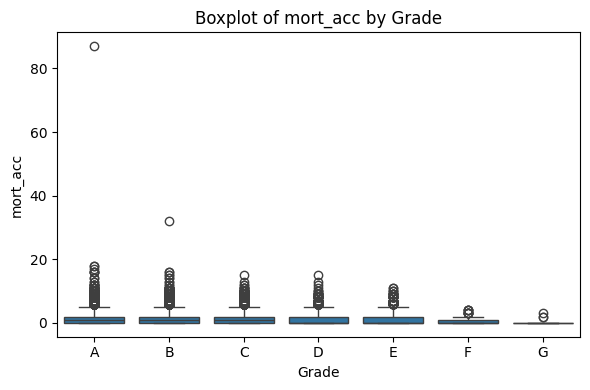

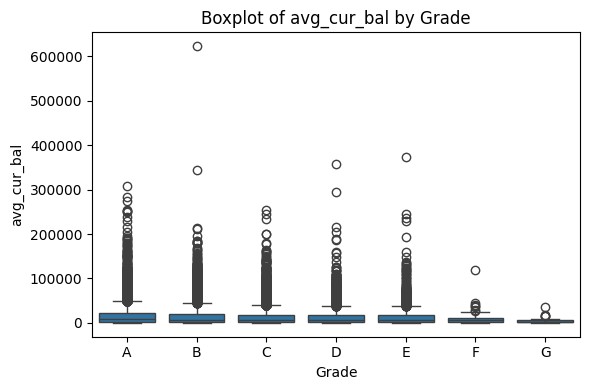

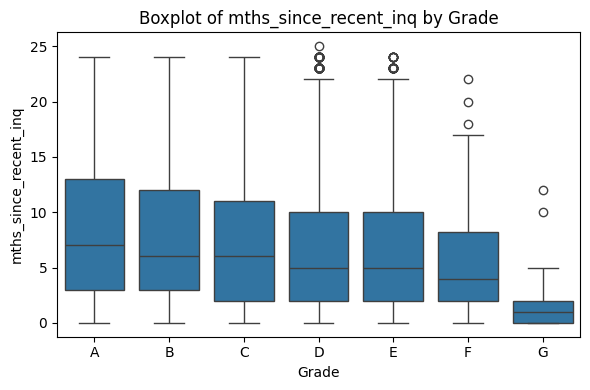

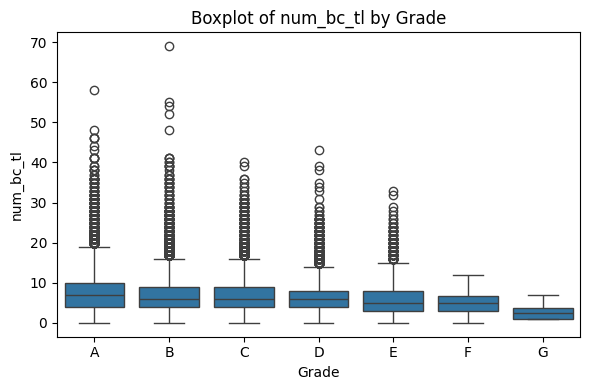

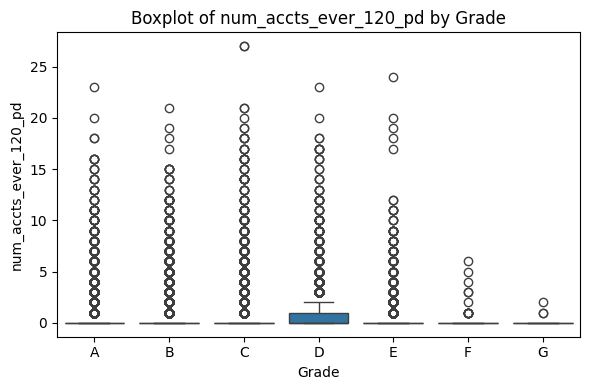

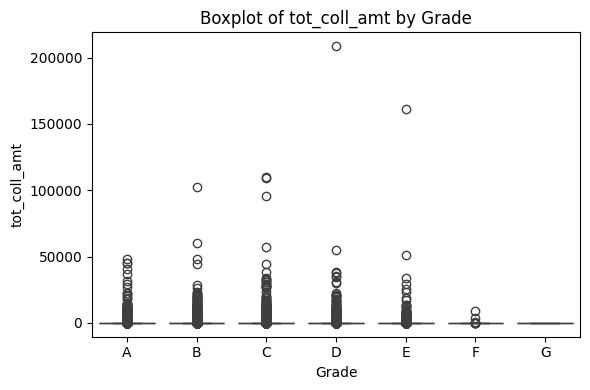

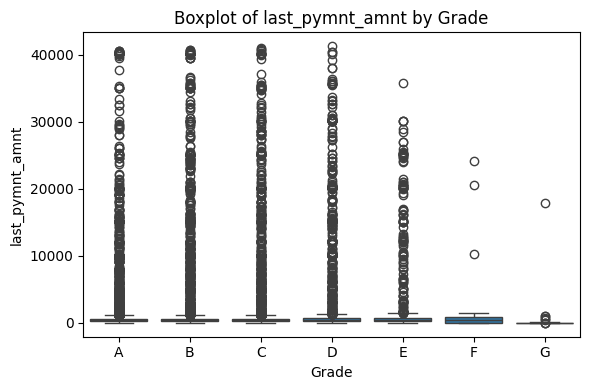

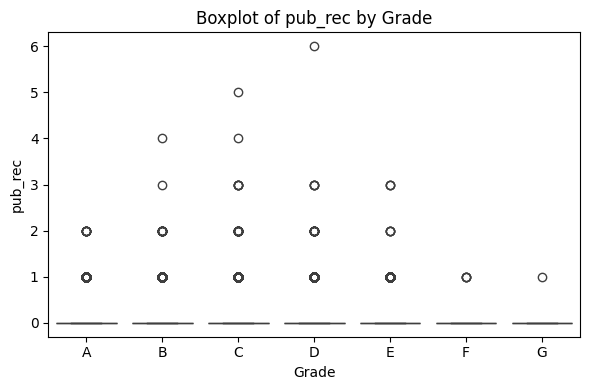

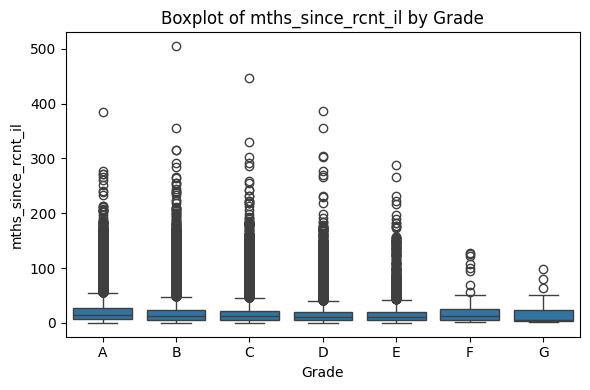

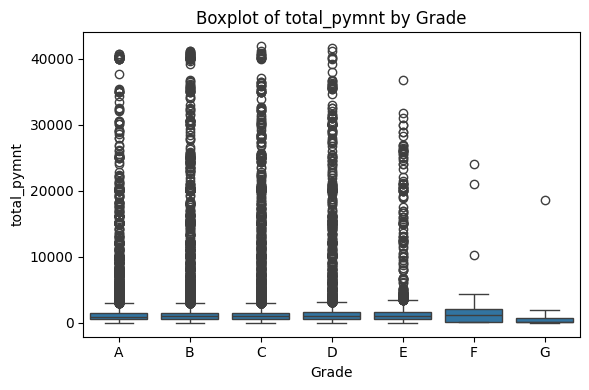

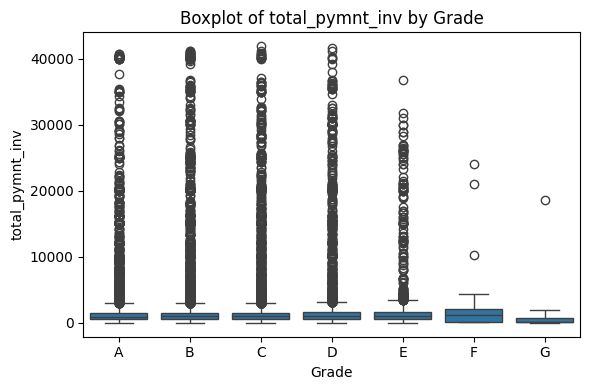

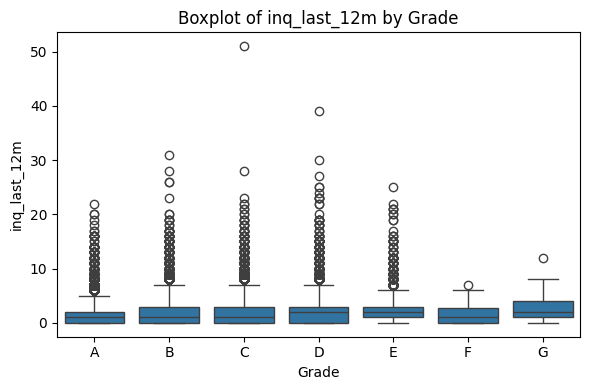

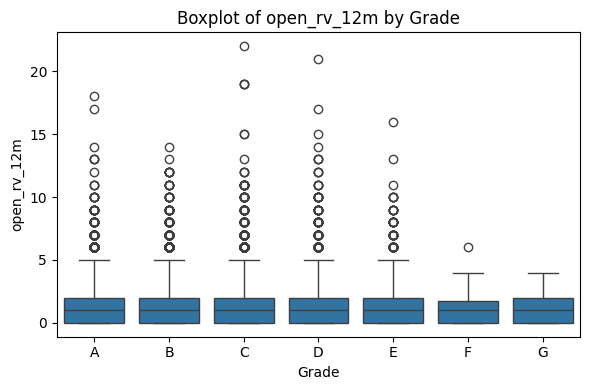

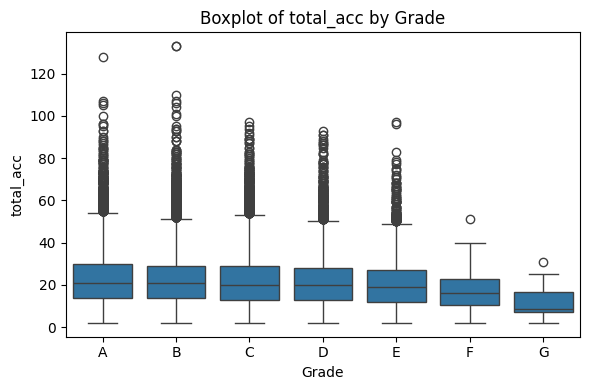

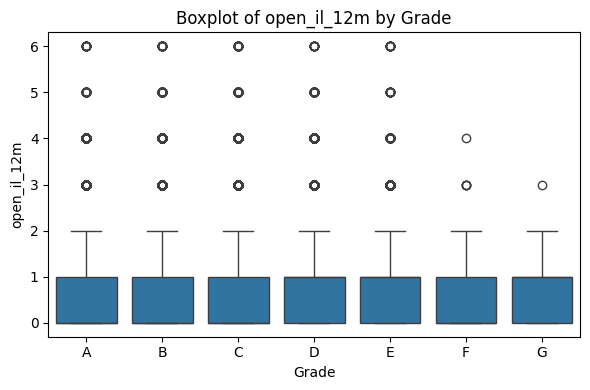

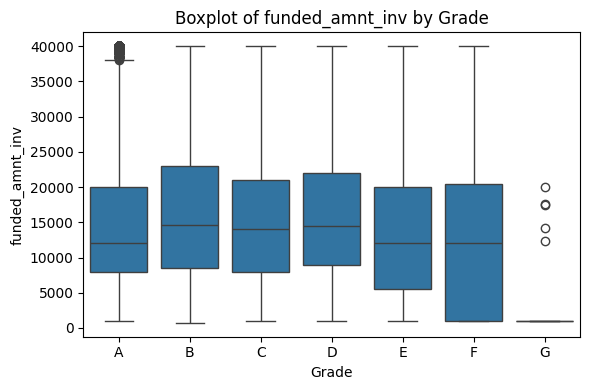

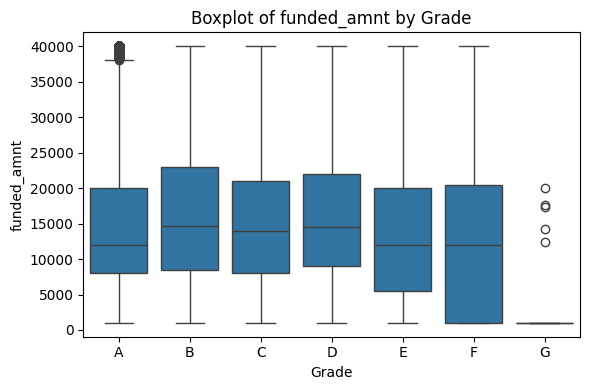

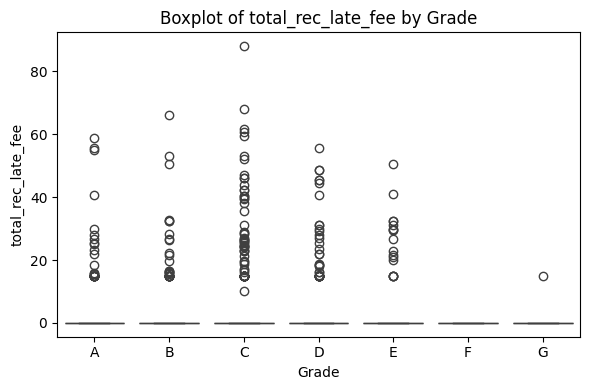

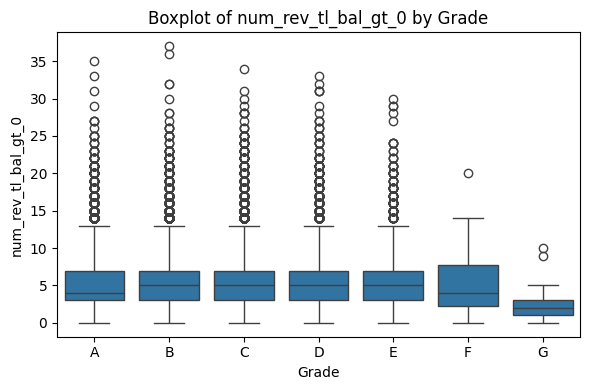

In [20]:
import seaborn as sns

num_features = set(kept) & set(numerical)

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='grade', y=col, order=sorted(df['grade'].unique()))
    plt.title(f'Boxplot of {col} by Grade')
    plt.xlabel('Grade')
    plt.ylabel(col)
    plt.tight_layout()

### Correlation between categorical variables and target

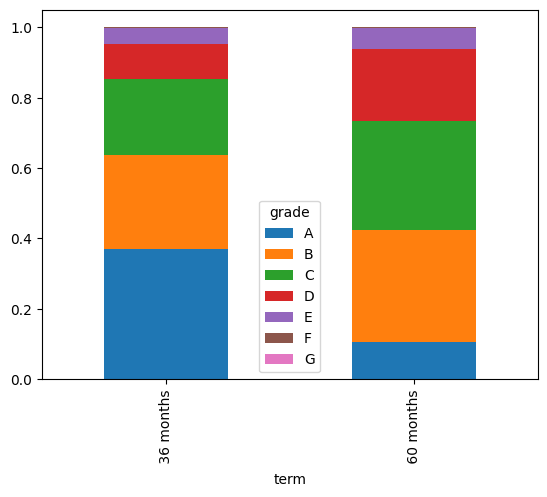

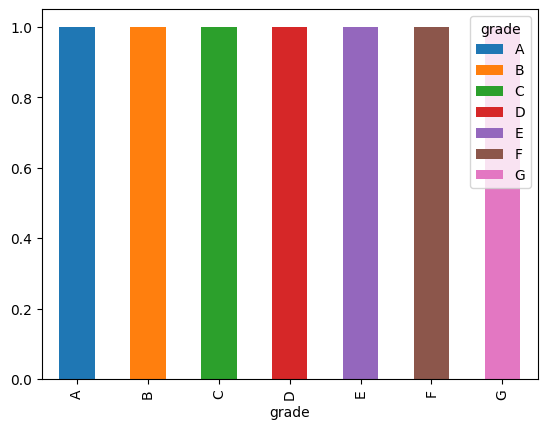

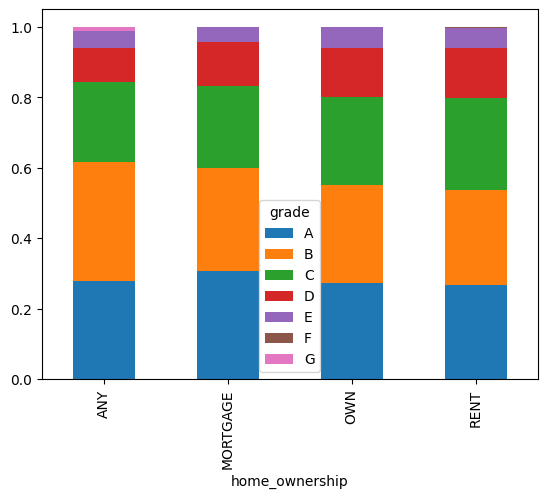

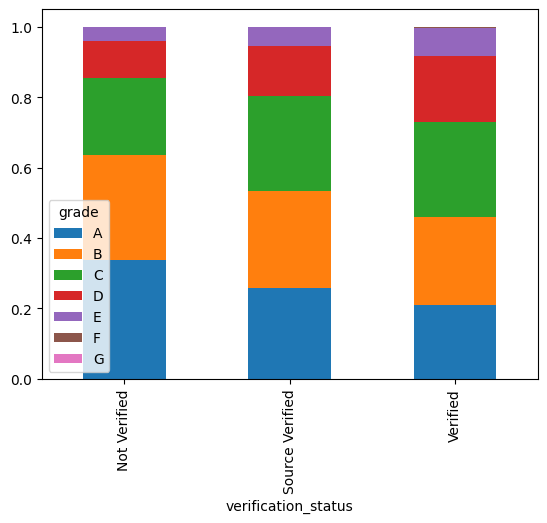

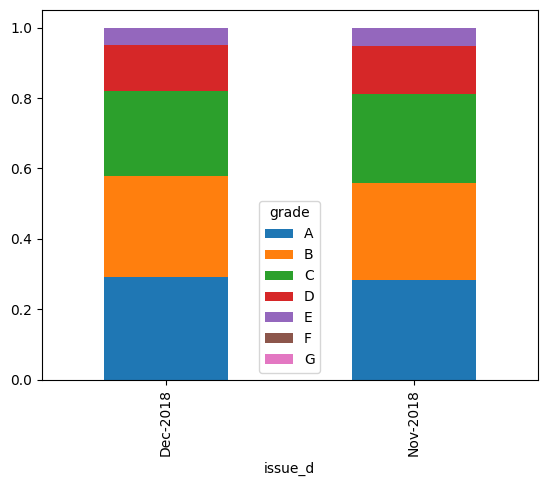

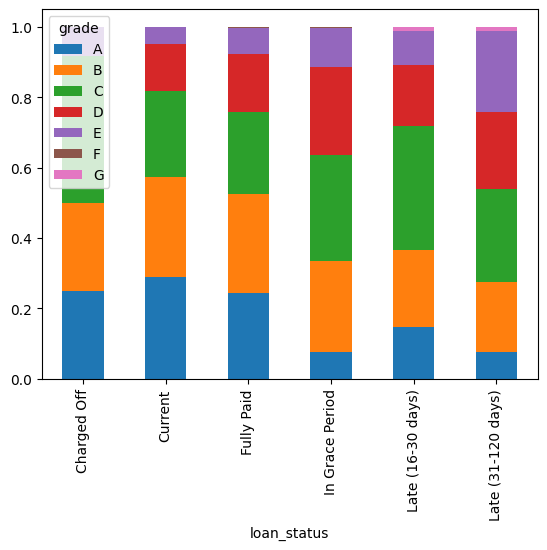

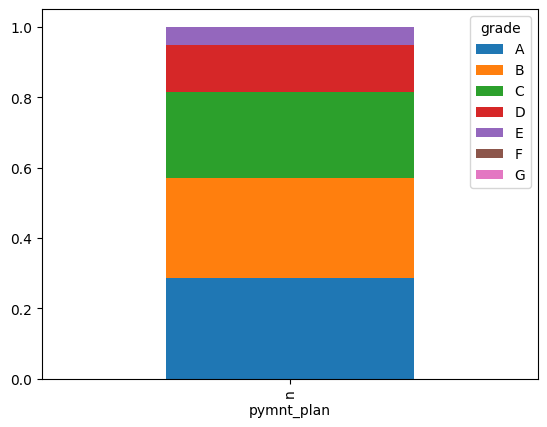

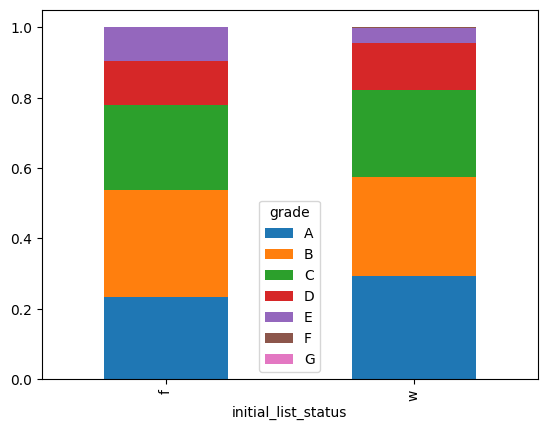

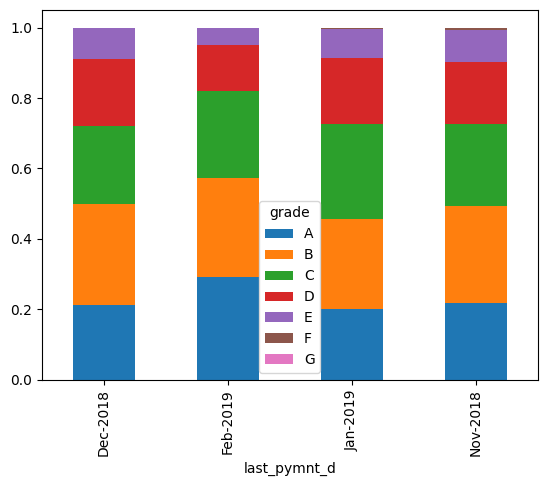

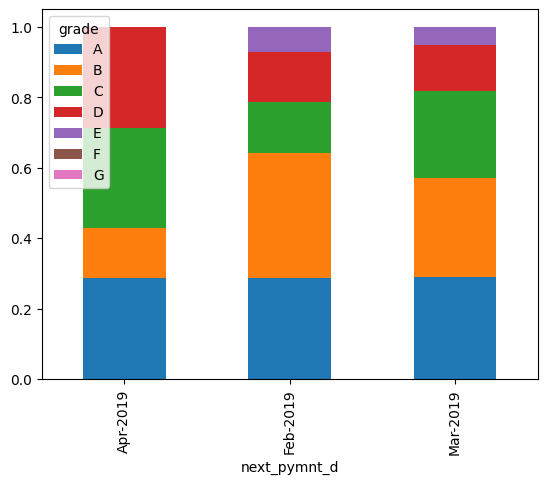

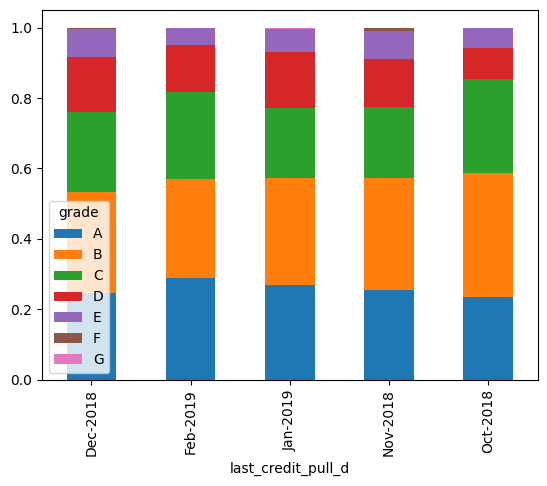

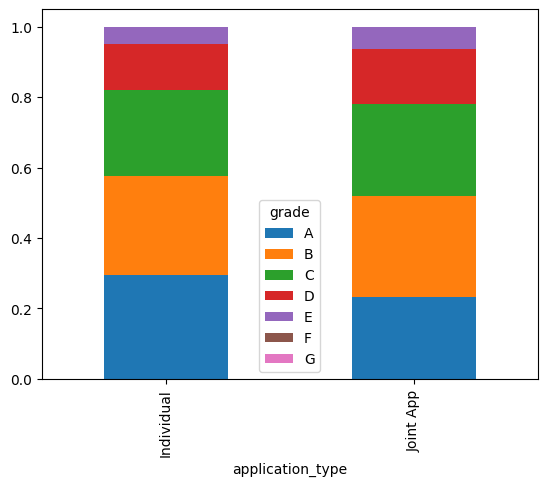

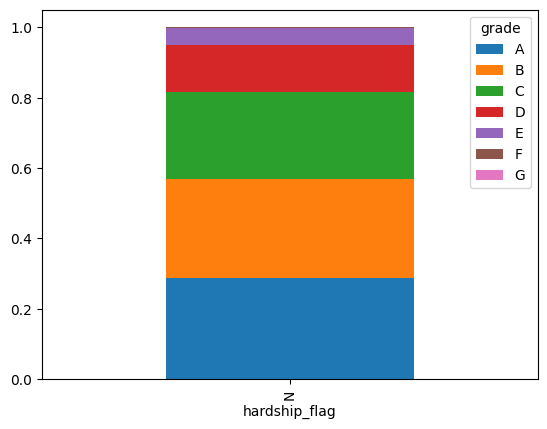

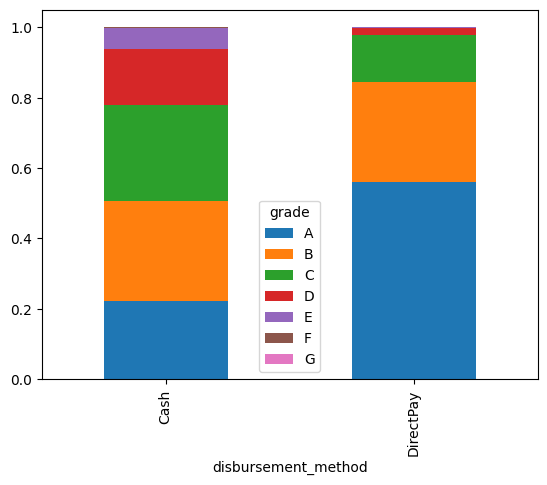

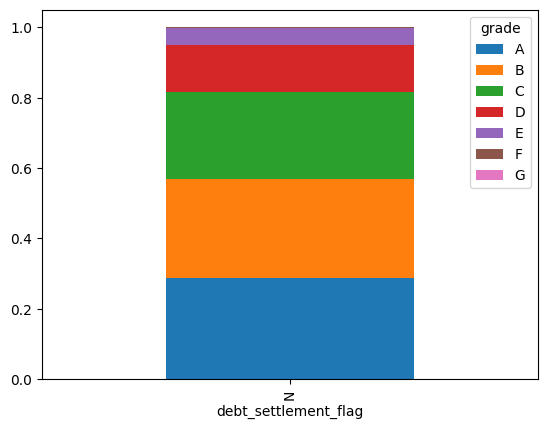

In [21]:

for var in categorical:
    if df[var].nunique() < 10: 
        pd.crosstab(df[var], df['grade'], normalize='index').plot(kind='bar', stacked=True)

### Check correlation

In [22]:
# Encode grade as numeric for correlation
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)

correlations = df.select_dtypes(include='number').corr()['grade_num'].sort_values().dropna()
print(correlations.tail(10))  # most positively correlated
print(correlations.head(10))  # most negatively correlated

inq_last_12m        0.109417
inq_last_6mths      0.110477
inq_fi              0.111590
revol_util          0.253572
bc_util             0.272731
percent_bc_gt_75    0.275811
all_util            0.280111
total_rec_int       0.415063
int_rate            0.972609
grade_num           1.000000
Name: grade_num, dtype: float64
bc_open_to_buy           -0.286312
total_bc_limit           -0.237688
total_rev_hi_lim         -0.198423
pct_tl_nvr_dlq           -0.119774
tot_hi_cred_lim          -0.102203
num_bc_tl                -0.098759
mths_since_recent_inq    -0.095439
mo_sin_old_rev_tl_op     -0.093376
mort_acc                 -0.093209
mths_since_last_delinq   -0.088302
Name: grade_num, dtype: float64


In [23]:
del df['grade_num']

<Axes: xlabel='grade'>

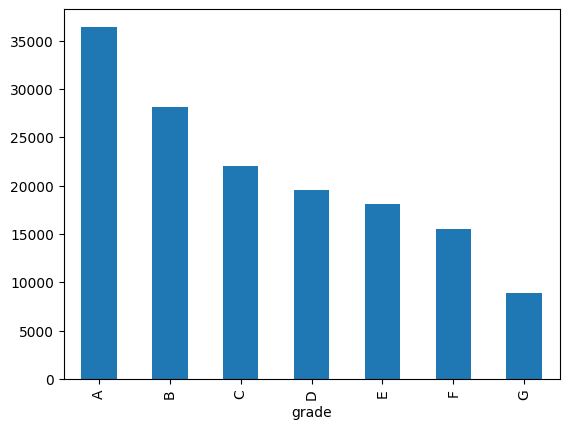

In [24]:
df.groupby('grade')['total_bc_limit'].mean().plot(kind='bar')

Text(0.5, 1.0, 'Feature Correlation Heatmap (|r| > 0.5)')

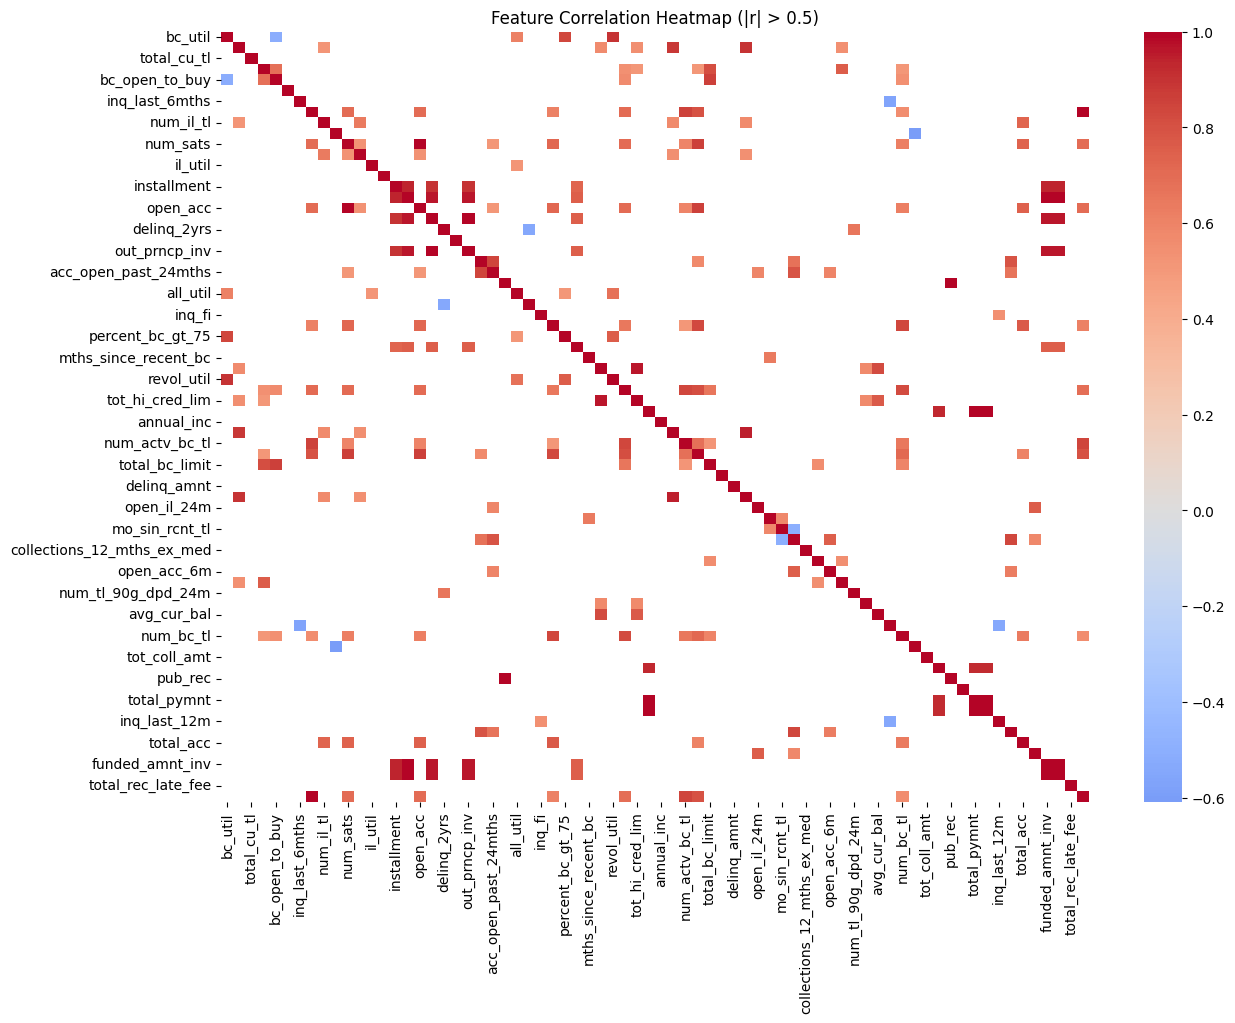

In [25]:
corr = df[list(num_features)].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            mask=corr.abs() < 0.5,  # only show meaningful correlations
            annot=False)
plt.title('Feature Correlation Heatmap (|r| > 0.5)')

### Target variable vs. missing value correlation

In [26]:
for col in df.columns[df.isnull().any()]:
    null_by_grade = df.groupby('grade')[col].apply(lambda x: x.isnull().mean())
    if null_by_grade.std() > 0.01:  # meaningful variation
        print(f"{col}:\n{null_by_grade}\n")

emp_title:
grade
A    0.162803
B    0.164457
C    0.173882
D    0.162216
E    0.166444
F    0.189189
G    0.346154
Name: emp_title, dtype: float64

emp_length:
grade
A    0.081610
B    0.090463
C    0.100803
D    0.100381
E    0.100293
F    0.108108
G    0.230769
Name: emp_length, dtype: float64

mths_since_last_delinq:
grade
A    0.637346
B    0.570101
C    0.505968
D    0.480225
E    0.503868
F    0.621622
G    0.692308
Name: mths_since_last_delinq, dtype: float64

revol_util:
grade
A    0.000325
B    0.000944
C    0.001139
D    0.002510
E    0.002401
F    0.000000
G    0.038462
Name: revol_util, dtype: float64

last_pymnt_d:
grade
A    0.000417
B    0.000944
C    0.001628
D    0.001907
E    0.005868
F    0.000000
G    0.076923
Name: last_pymnt_d, dtype: float64

next_pymnt_d:
grade
A    0.019568
B    0.023170
C    0.021864
D    0.028508
E    0.034676
F    0.040541
G    0.115385
Name: next_pymnt_d, dtype: float64

mths_since_rcnt_il:
grade
A    0.030140
B    0.031853
C    0.037164
D 

### Recheck missing values

In [27]:
df.isnull().mean().sort_values(ascending = False)

,0
mths_since_last_delinq,0.558520
emp_title,0.166187
il_util,0.154427
mths_since_recent_inq,0.120893
emp_length,0.092333
mths_since_rcnt_il,0.033667
mo_sin_old_il_acct,0.033667
num_tl_120dpd_2m,0.024107
next_pymnt_d,0.023147
bc_util,0.013840


#### Drop categorical variables with more than 10 levels

This helps save the computation from encoding categorical variables

In [28]:
for var in categorical:
    if df[var].nunique() > 10:
        del df[var]

#### Drop variables with target leakage

Many of these columns describe what happened after the loan was issued, not at origination.

In [86]:
leakage_cols = [
    # Post-origination payment data
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_amnt',
    'out_prncp', 'out_prncp_inv', 'disbursement_method',
    
    # Loan status after origination
    'loan_status',
    
    # Payment plan info
    'pymnt_plan', 'last_pymnt_d',
    
    # Next payment date (post-origination)
    'next_pymnt_d',
    
    # Hardship/settlement (post-origination)
    'hardship_flag', 'debt_settlement_flag',
    
    # Already removing these
    'int_rate', 'sub_grade'
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

### Data split

In [87]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, stratify=df['grade'])
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, stratify=df_full_train['grade'])

df_train.shape, df_val.shape, df_test.shape

((45000, 77), (15000, 77), (15000, 77))

In [88]:
y_train = df_train['grade']
y_val = df_val['grade']
y_test = df_test['grade']

del df_train['grade']
del df_val['grade']
del df_test['grade']


### Data preprocessing

In [89]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse = False)

train_dict = df_train.to_dict(orient = 'records')
val_dict = df_val.to_dict(orient = 'records')
test_dict = df_test.to_dict(orient = 'records')

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)



## Model development

#### Baseline model

In [90]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=10, criterion='log_loss', max_features='sqrt', max_depth=5,
                               random_state=42, n_jobs=-1)


model.fit(X_train, y_train)



RandomForestClassifier(criterion='log_loss', max_depth=5, n_estimators=10,
                       n_jobs=-1, random_state=42)

In [91]:
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict_proba(X_val)
y_pred_class = model.predict(X_val)

print('log loss is', log_loss(y_val, y_pred))



log loss is 1.3347749545510466


#### Feature importance

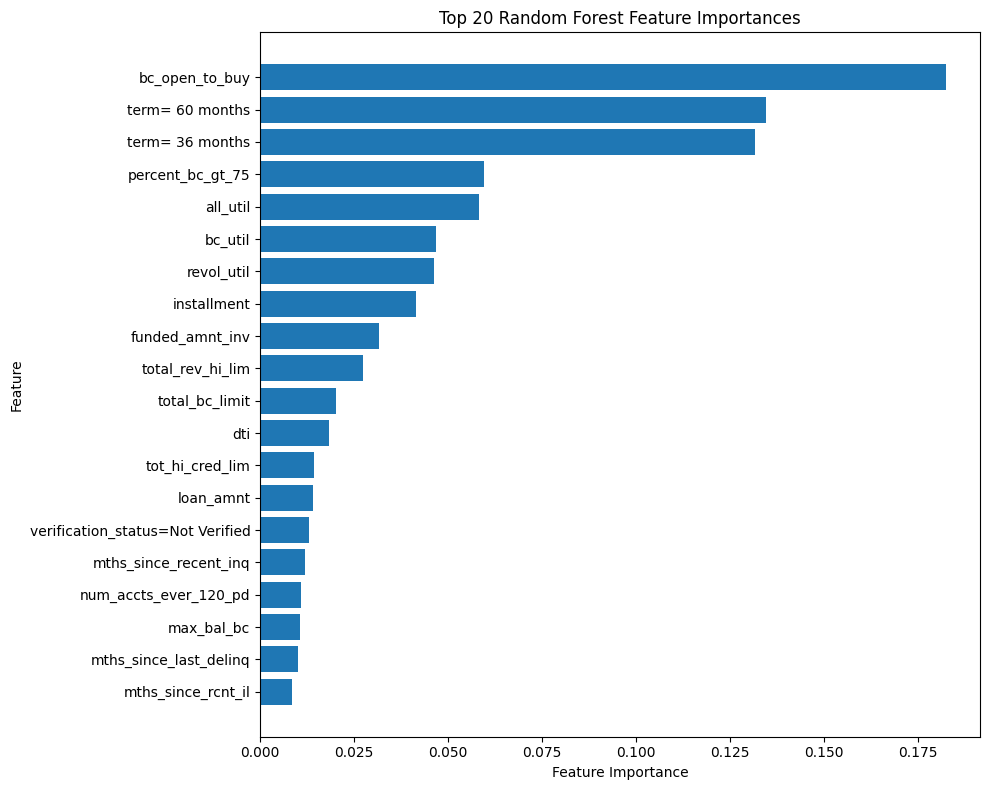

In [92]:
# feature names
feature_names = dv.get_feature_names_out()

# importance dataframe
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# top 20 features
top_n = 20
fi_top = fi.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#### Hyperparameter tuning


In [93]:

scores = []

for depth in [5, 7, 9, 11, 13]:

    for min_samples in [10, 20, 30, 40]:

        model = RandomForestClassifier(n_estimators=50, 
                                       criterion='log_loss', 
                                       max_features='sqrt', 
                                       max_depth=depth,
                                       min_samples_leaf=min_samples,
                                       random_state=42, 
                                       n_jobs=-1)

        model.fit(X_train, y_train)

        from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

        y_prob = model.predict_proba(X_val)
        # for multi-class problems
        y_pred = model.classes_[y_prob.argmax(axis=1)]

        accuracy = accuracy_score(y_val, y_pred)

        logloss = log_loss(y_val, y_prob)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')


        scores.append([depth, min_samples, accuracy, logloss, macro_f1, weighted_f1])

scores_df = pd.DataFrame(scores, columns = ['max_depth', 'min_samples_leaf', 'accuracy', 'logloss', 'F1 score macro', 'F1 score weighted'])

    

In [94]:
scores_df

,max_depth,min_samples_leaf,accuracy,logloss,F1 score macro,F1 score weighted
0,5,10,0.426467,1.334146,0.206513,0.379479
1,5,20,0.426733,1.336454,0.206679,0.379805
2,5,30,0.423600,1.337059,0.202172,0.375742
3,5,40,0.424133,1.335549,0.202230,0.376142
4,7,10,0.443667,1.297171,0.225883,0.402505
5,7,20,0.448933,1.293860,0.229973,0.408852
6,7,30,0.446600,1.294054,0.225573,0.405123
7,7,40,0.439133,1.299910,0.217984,0.394983
8,9,10,0.465400,1.263913,0.246347,0.430681
9,9,20,0.463067,1.263391,0.242552,0.427356


In [95]:
def visualize_metric(metric = 'F1 score macro'):

    pivot = scores_df.pivot(
        index='max_depth',
        columns='min_samples_leaf',
        values=metric
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot, aspect='auto')
    plt.colorbar(label=metric)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel('min_samples_leaf')
    plt.ylabel('max_depth')
    plt.title(f'Hyperparameter tuning heatmap: {metric}')
    plt.show()

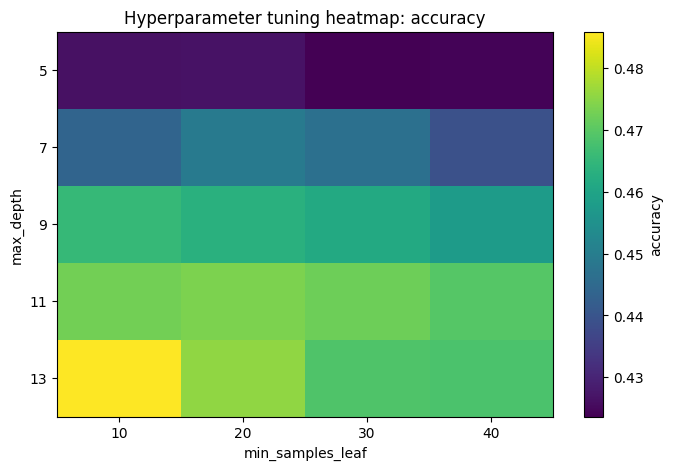

In [96]:
visualize_metric(metric = 'accuracy')

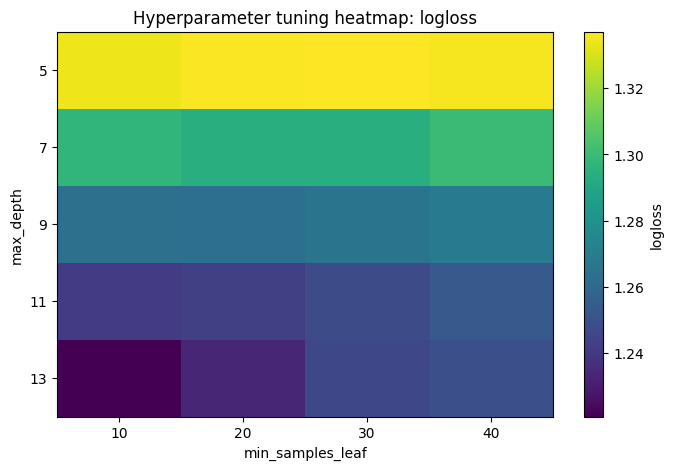

In [97]:
visualize_metric(metric = 'logloss')

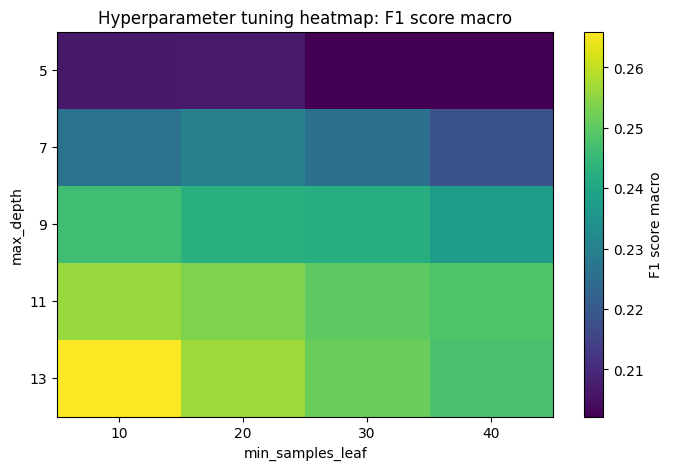

In [98]:
visualize_metric(metric = 'F1 score macro')

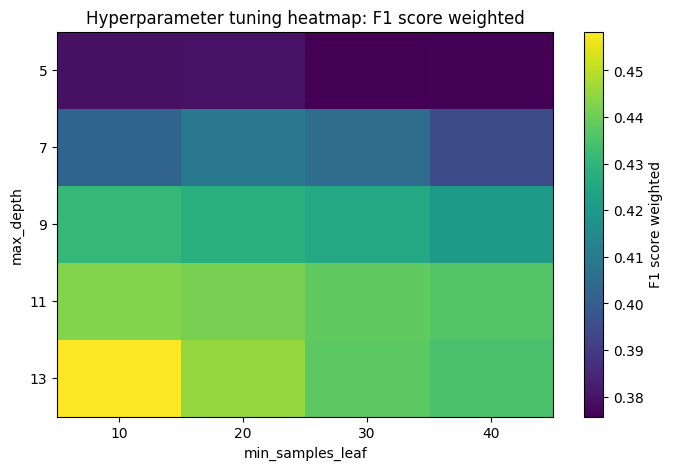

In [99]:
visualize_metric(metric = 'F1 score weighted')

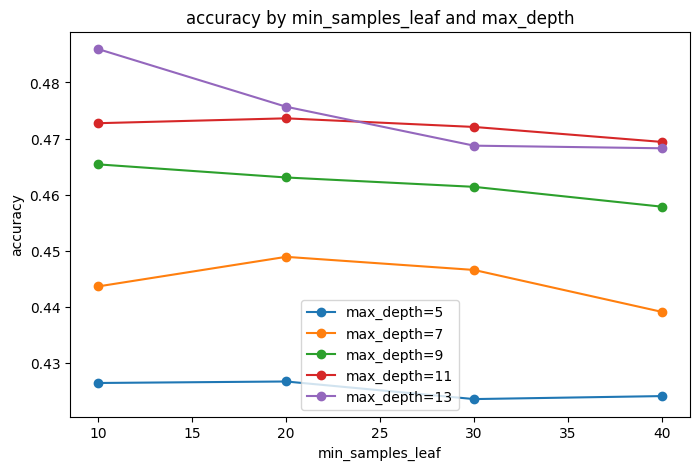

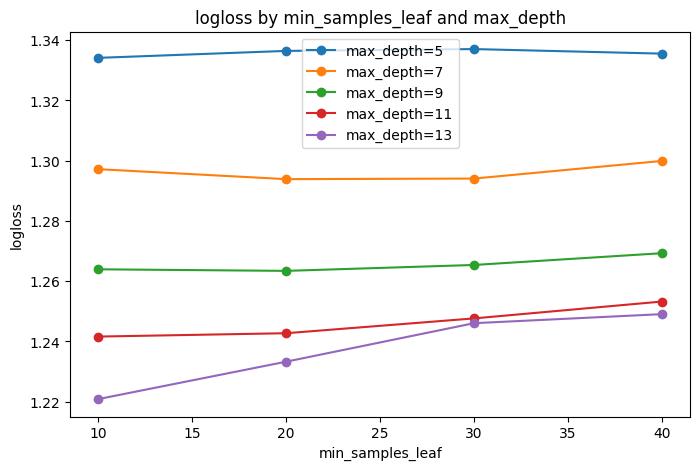

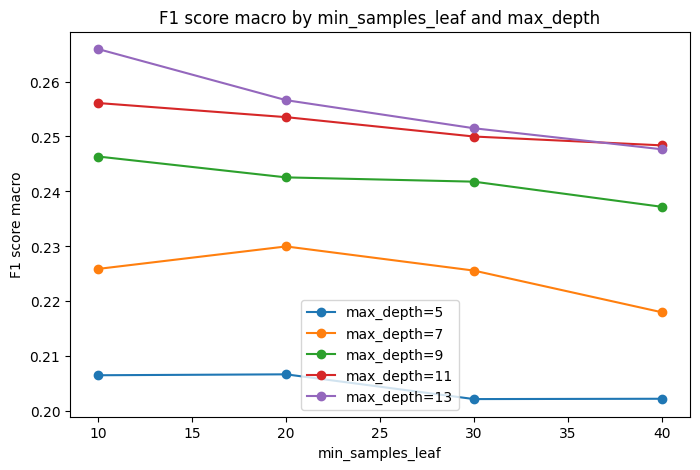

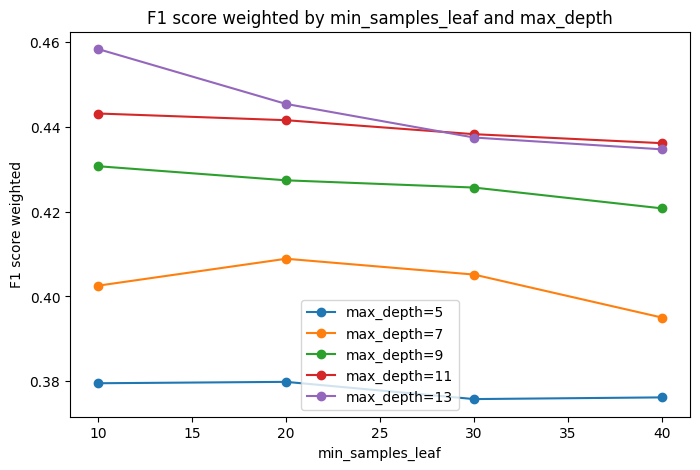

In [100]:

for metric in ['accuracy', 'logloss', 'F1 score macro', 'F1 score weighted']:

    plt.figure(figsize=(8, 5))

    for depth in sorted(scores_df['max_depth'].unique()):
        subset = scores_df[scores_df['max_depth'] == depth].sort_values('min_samples_leaf')
        plt.plot(subset['min_samples_leaf'], subset[metric], marker='o', label=f'max_depth={depth}')

    plt.xlabel('min_samples_leaf')
    plt.ylabel(metric)
    plt.title(f'{metric} by min_samples_leaf and max_depth')
    plt.legend()
    plt.show()

In [101]:
# Conclusion

# The best combination of hyperparameters -

max_depth = 13
min_samples_leaf = 10

#### Finalize random forest model

In [102]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, 
                                criterion='log_loss', 
                                max_features='sqrt', 
                                max_depth=max_depth,
                                min_samples_leaf=min_samples_leaf,
                                random_state=42, 
                                n_jobs=-1)

rf_model.fit(X_train, y_train)

RandomForestClassifier(criterion='log_loss', max_depth=13, min_samples_leaf=10,
                       n_estimators=50, n_jobs=-1, random_state=42)

In [103]:
import joblib

# Save
joblib.dump(rf_model, 'random_forest_model.pkl')

# Load back
rf_model = joblib.load('random_forest_model.pkl')

In [118]:
def model_perf(X = X_val, y = y_val):

    from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

    y_prob = rf_model.predict_proba(X)
    # for multi-class problems
    y_pred = rf_model.classes_[y_prob.argmax(axis=1)]

    accuracy = accuracy_score(y, y_pred)

    logloss = log_loss(y, y_prob)
    macro_f1 = f1_score(y, y_pred, average='macro')
    weighted_f1 = f1_score(y, y_pred, average='weighted')

    print(classification_report(y, y_pred))

In [119]:
model_perf(X = X_val, y = y_val)

              precision    recall  f1-score   support

           A       0.58      0.74      0.65      4313
           B       0.45      0.43      0.44      4238
           C       0.40      0.53      0.46      3686
           D       0.51      0.14      0.23      1993
           E       0.47      0.05      0.09       750
           F       0.00      0.00      0.00        15
           G       0.00      0.00      0.00         5

    accuracy                           0.49     15000
   macro avg       0.35      0.27      0.27     15000
weighted avg       0.48      0.49      0.46     15000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [120]:
model_perf(X = X_test, y = y_test)

              precision    recall  f1-score   support

           A       0.58      0.75      0.65      4313
           B       0.43      0.41      0.42      4238
           C       0.40      0.53      0.45      3687
           D       0.50      0.13      0.21      1992
           E       0.47      0.05      0.10       750
           F       0.00      0.00      0.00        15
           G       0.00      0.00      0.00         5

    accuracy                           0.48     15000
   macro avg       0.34      0.27      0.26     15000
weighted avg       0.48      0.48      0.45     15000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Feature importance

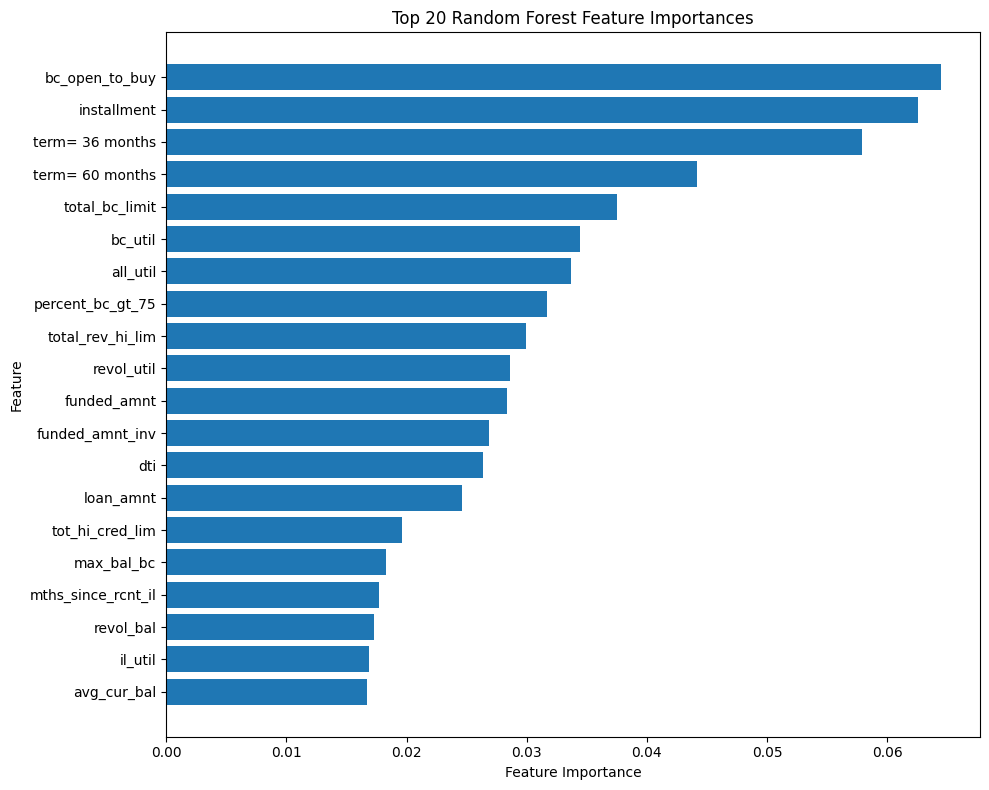

In [107]:
# feature names
feature_names = dv.get_feature_names_out()

# importance dataframe
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# top 20 features
top_n = 20
fi_top = fi.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#### XGBoost

In [122]:
import xgboost as xgb

Prepare Data
XGBoost needs integer-encoded labels just like PyTorch:

Reuse your existing LabelEncoder from PyTorch section
y_train_enc, y_val_enc, y_test_enc already encoded as 0-6

In [123]:
# Encode target to integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # 'A'->0, 'B'->1, etc.
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [124]:
model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    device='cuda',              # GPU
    tree_method='hist',         # required for GPU
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=20,   # stops if val loss doesn't improve
    random_state=42
)

model_xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    verbose=50                  # print every 50 rounds
)

[0]	validation_0-mlogloss:1.45555


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:56:26] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:56:26] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:56:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-mlogloss:0.87261
[100]	validation_0-mlogloss:0.62851
[150]	validation_0-mlogloss:0.48570
[200]	validation_0-mlogloss:0.40425
[250]	validation_0-mlogloss:0.35334
[300]	validation_0-mlogloss:0.31757
[350]	validation_0-mlogloss:0.28701
[400]	validation_0-mlogloss:0.27053
[450]	validation_0-mlogloss:0.25572
[499]	validation_0-mlogloss:0.24224


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=20,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=7, ...)

In [125]:
# evaluate 
def model_perf(X = X_val, y = y_val_enc):
    y_pred_xgb = model_xgb.predict(X)

    # Decode back to grade labels
    y_pred_labels = le.inverse_transform(y_pred_xgb)
    y_labels = le.inverse_transform(y)

    print(classification_report(y_labels, y_pred_labels, target_names=list('ABCDEFG')))
    print(f"Weighted F1: {f1_score(y_labels, y_pred_labels, average='weighted'):.4f}")
    print(f"Macro F1:    {f1_score(y_labels, y_pred_labels, average='macro'):.4f}")

In [126]:
model_perf(X = X_train, y = y_train_enc)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00     12940
           B       0.99      0.99      0.99     12715
           C       0.99      1.00      1.00     11059
           D       1.00      1.00      1.00      5977
           E       1.00      1.00      1.00      2249
           F       1.00      1.00      1.00        44
           G       1.00      1.00      1.00        16

    accuracy                           1.00     45000
   macro avg       1.00      1.00      1.00     45000
weighted avg       1.00      1.00      1.00     45000

Weighted F1: 0.9963
Macro F1:    0.9979


In [127]:
model_perf(X = X_val, y = y_val_enc)

              precision    recall  f1-score   support

           A       0.97      0.97      0.97      4313
           B       0.92      0.93      0.92      4238
           C       0.91      0.91      0.91      3686
           D       0.92      0.90      0.91      1993
           E       0.92      0.89      0.90       750
           F       0.00      0.00      0.00        15
           G       0.50      0.20      0.29         5

    accuracy                           0.93     15000
   macro avg       0.73      0.69      0.70     15000
weighted avg       0.93      0.93      0.93     15000

Weighted F1: 0.9304
Macro F1:    0.7009


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [128]:
model_perf(X = X_test, y = y_test_enc)

              precision    recall  f1-score   support

           A       0.98      0.97      0.97      4313
           B       0.92      0.94      0.93      4238
           C       0.91      0.92      0.92      3687
           D       0.93      0.91      0.92      1992
           E       0.90      0.91      0.91       750
           F       0.00      0.00      0.00        15
           G       0.00      0.00      0.00         5

    accuracy                           0.94     15000
   macro avg       0.66      0.66      0.66     15000
weighted avg       0.94      0.94      0.94     15000

Weighted F1: 0.9361
Macro F1:    0.6643


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                             feature  importance
74                   term= 36 months    0.063126
75                   term= 60 months    0.058982
34                         loan_amnt    0.058180
14                       funded_amnt    0.048270
15                   funded_amnt_inv    0.043822
7                     bc_open_to_buy    0.043631
26                       installment    0.043275
67                  percent_bc_gt_75    0.023341
25                    inq_last_6mths    0.019620
86  verification_status=Not Verified    0.019137
22             initial_list_status=w    0.017294
1               acc_open_past_24mths    0.016793
55                  num_tl_120dpd_2m    0.015315
11                       delinq_2yrs    0.014948
58                num_tl_op_past_12m    0.014627
21             initial_list_status=f    0.013526
85                  total_rev_hi_lim    0.013072
40                          mort_acc    0.012880
29       last_credit_pull_d=Dec-2018    0.012323
2                   

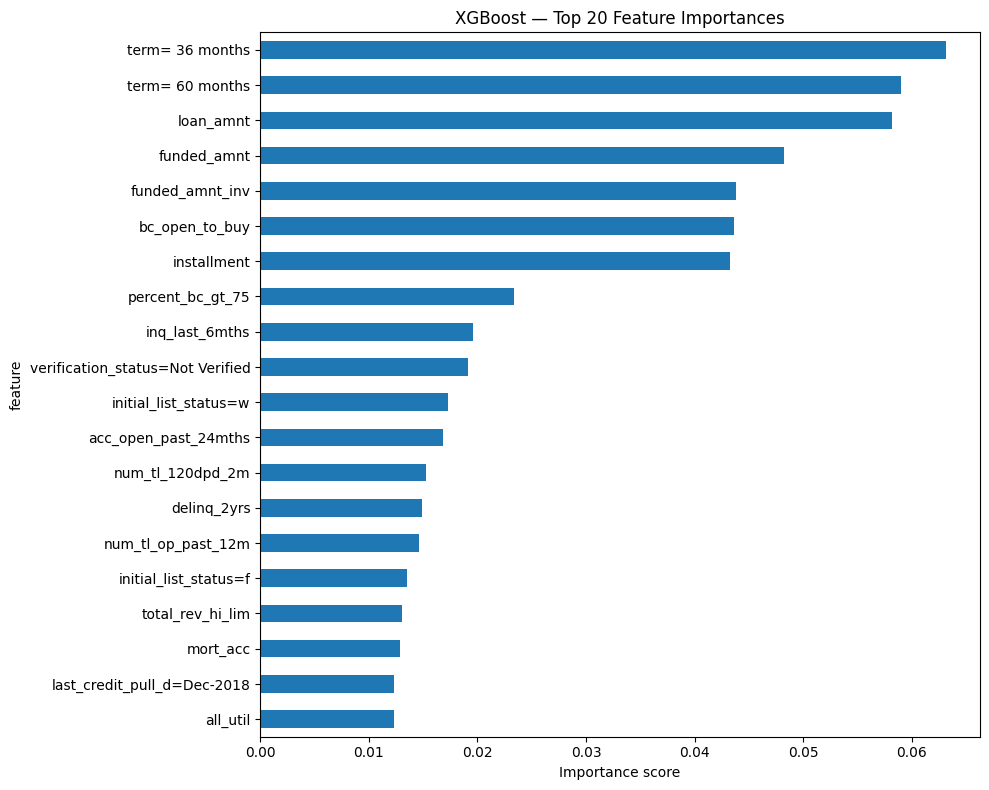

In [129]:

# ── Get feature importance ────────────────────────────────────────────────────
importance = model_xgb.feature_importances_
feature_names = dv.feature_names_

# ── Create a sorted dataframe ─────────────────────────────────────────────────
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feat_imp_df.head(20))

# ── Plot top 20 ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
feat_imp_df.head(20).plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False,
    ax=plt.gca()
)
plt.gca().invert_yaxis()
plt.title('XGBoost — Top 20 Feature Importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

#### Neural Networks - MLP

1. Prepare the Data for PyTorch

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # should print: Using device: cuda

Using device: cuda


In [20]:
import numpy as np
import pandas as pd
import kagglehub
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import classification_report, f1_score

def load_data(nrows = 75000):
    # Download latest version
    path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")
    df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = nrows)
    drop_missing_columns = list(df.columns[df.isnull().sum() > 50000])
    df.drop(columns = drop_missing_columns, inplace=True)

    numerical = list(df.dtypes[df.dtypes != 'object'].index)
    categorical = list(df.dtypes[df.dtypes == 'object'].index)

    selector = VarianceThreshold(threshold=0.01)  

    numeric_cols = df.select_dtypes(include='number').columns

    selector.fit(df[numeric_cols])

    kept = numeric_cols[selector.get_support()]
    dropped = numeric_cols[~selector.get_support()]

    for var in categorical:
        if df[var].nunique() > 10:
            del df[var]

    leakage_cols = [
        # Post-origination payment data
        'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
        'total_rec_int', 'total_rec_late_fee', 'recoveries',
        'collection_recovery_fee', 'last_pymnt_amnt',
        'out_prncp', 'out_prncp_inv', 'disbursement_method',
        
        # Loan status after origination
        'loan_status',
        
        # Payment plan info
        'pymnt_plan',
        
        # Next payment date (post-origination)
    '   pymnt_plan', 'last_pymnt_d',
        
        # Hardship/settlement (post-origination)
        'hardship_flag', 'debt_settlement_flag',
        
        # Already removing these
        'int_rate', 'sub_grade'
    ]
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    df_full_train, df_test = train_test_split(df, test_size = 0.2, stratify=df['grade'])
    df_train, df_val = train_test_split(df_full_train, test_size = 0.25, stratify=df_full_train['grade'])

    y_train = df_train['grade']
    y_val = df_val['grade']
    y_test = df_test['grade']

    del df_train['grade']
    del df_val['grade']
    del df_test['grade']



    dv = DictVectorizer(sparse = False)

    train_dict = df_train.to_dict(orient = 'records')
    val_dict = df_val.to_dict(orient = 'records')
    test_dict = df_test.to_dict(orient = 'records')

    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)
    X_test = dv.transform(test_dict)

    return X_train, X_val, X_test, y_train, y_val, y_test, dv

#### Data preprocessing

In [21]:
X_train, X_val, X_test, y_train, y_val, y_test, dv = load_data(nrows = 500000)

Using Colab cache for faster access to the 'lending-club-loan-data-csv' dataset.


/tmp/ipykernel_1379/2492639203.py:13: DtypeWarning: Columns (112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = nrows)


In [22]:
# missing values treatment
# this is a must for torch
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

In [23]:
# scale the input features
# this turns out to be extremely important in improving model performance!!!!

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [24]:

# Encode target to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # 'A'->0, 'B'->1, etc.
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# Convert to tensors — X_train is already our DictVectorizer output
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.LongTensor(y_train_enc)
y_val_tensor = torch.LongTensor(y_val_enc)
y_test_tensor = torch.LongTensor(y_test_enc)

In [25]:
# create dataset class

class LoanDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [26]:
# create dataloaders

train_loader = DataLoader(
    LoanDataset(X_train_tensor, y_train_tensor),
    batch_size=512,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)
val_loader = DataLoader(
    LoanDataset(X_val_tensor, y_val_tensor),
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)
test_loader = DataLoader(
    LoanDataset(X_test_tensor, y_test_tensor),
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

In [27]:
# model 
class LoanGradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super(LoanGradeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [28]:
input_dim = X_train.shape[1]
model = LoanGradeMLP(input_dim=input_dim, num_classes=7).to(device)

In [29]:

# ── Loss, optimizer, scheduler ────────────────────────────────────────────────
class_counts  = np.bincount(y_train_enc)
class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [30]:
# ── Train / eval functions ────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [31]:
# ── Training loop ─────────────────────────────────────────────────────────────
num_epochs    = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_nn_model.pth')
        print("  -> Best model saved")

Epoch 01 | Train Loss: 1.5460  Acc: 0.3673 | Val Loss: 1.2590  Acc: 0.4698
  -> Best model saved
Epoch 02 | Train Loss: 1.1670  Acc: 0.5120 | Val Loss: 0.8607  Acc: 0.6905
  -> Best model saved
Epoch 03 | Train Loss: 0.9539  Acc: 0.6133 | Val Loss: 0.7368  Acc: 0.7535
  -> Best model saved
Epoch 04 | Train Loss: 0.8521  Acc: 0.6569 | Val Loss: 0.6083  Acc: 0.7997
  -> Best model saved
Epoch 05 | Train Loss: 0.7699  Acc: 0.6929 | Val Loss: 0.5941  Acc: 0.7923
  -> Best model saved
Epoch 06 | Train Loss: 0.7413  Acc: 0.7085 | Val Loss: 0.5438  Acc: 0.8357
  -> Best model saved
Epoch 07 | Train Loss: 0.6893  Acc: 0.7300 | Val Loss: 0.5411  Acc: 0.8155
  -> Best model saved
Epoch 08 | Train Loss: 0.6619  Acc: 0.7404 | Val Loss: 0.4841  Acc: 0.8519
  -> Best model saved
Epoch 09 | Train Loss: 0.6347  Acc: 0.7525 | Val Loss: 0.4739  Acc: 0.8597
  -> Best model saved
Epoch 10 | Train Loss: 0.6321  Acc: 0.7554 | Val Loss: 0.4716  Acc: 0.8521
  -> Best model saved
Epoch 11 | Train Loss: 0.6058 

In [32]:
# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score

model.load_state_dict(torch.load('best_nn_model.pth'))
model.eval()

all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)

y_pred_labels = le.inverse_transform(all_preds)
y_test_labels = le.inverse_transform(y_test_enc)

print(classification_report(y_test_labels, y_pred_labels, target_names=list('ABCDEFG')))
print(f"Weighted F1: {f1_score(y_test_labels, y_pred_labels, average='weighted'):.4f}")
print(f"Macro F1:    {f1_score(y_test_labels, y_pred_labels, average='macro'):.4f}")

              precision    recall  f1-score   support

           A       0.91      0.95      0.93     27220
           B       0.86      0.81      0.84     28550
           C       0.86      0.84      0.85     25656
           D       0.88      0.87      0.87     13924
           E       0.74      0.89      0.81      3845
           F       0.59      0.75      0.66       666
           G       0.35      0.69      0.46       139

    accuracy                           0.87    100000
   macro avg       0.74      0.83      0.77    100000
weighted avg       0.87      0.87      0.87    100000

Weighted F1: 0.8668
Macro F1:    0.7741


#### Increase model complexity

In [33]:
# model 
class LoanGradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super(LoanGradeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),  # increase neurons
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [34]:
input_dim = X_train.shape[1]
model = LoanGradeMLP(input_dim=input_dim, num_classes=7).to(device)

In [35]:

# ── Loss, optimizer, scheduler ────────────────────────────────────────────────
class_counts  = np.bincount(y_train_enc)
class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [36]:
# ── Training loop ─────────────────────────────────────────────────────────────
num_epochs = 50  # increase to 50
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_nn_v2_model.pth')
        print("  -> Best model saved")

Epoch 01 | Train Loss: 1.4395  Acc: 0.4094 | Val Loss: 1.1309  Acc: 0.5206
  -> Best model saved
Epoch 02 | Train Loss: 1.0640  Acc: 0.5506 | Val Loss: 0.8108  Acc: 0.6814
  -> Best model saved
Epoch 03 | Train Loss: 0.8575  Acc: 0.6484 | Val Loss: 0.6481  Acc: 0.7612
  -> Best model saved
Epoch 04 | Train Loss: 0.7541  Acc: 0.6992 | Val Loss: 0.5710  Acc: 0.8155
  -> Best model saved
Epoch 05 | Train Loss: 0.6978  Acc: 0.7234 | Val Loss: 0.5407  Acc: 0.8211
  -> Best model saved
Epoch 06 | Train Loss: 0.6484  Acc: 0.7470 | Val Loss: 0.5904  Acc: 0.7736
Epoch 07 | Train Loss: 0.6375  Acc: 0.7484 | Val Loss: 0.5025  Acc: 0.8506
  -> Best model saved
Epoch 08 | Train Loss: 0.6004  Acc: 0.7650 | Val Loss: 0.4920  Acc: 0.8401
Epoch 09 | Train Loss: 0.6020  Acc: 0.7677 | Val Loss: 0.4853  Acc: 0.8540
  -> Best model saved
Epoch 10 | Train Loss: 0.5662  Acc: 0.7803 | Val Loss: 0.4821  Acc: 0.8558
  -> Best model saved
Epoch 11 | Train Loss: 0.5527  Acc: 0.7840 | Val Loss: 0.4744  Acc: 0.8415

In [37]:
# ── Evaluation ────────────────────────────────────────────────────────────────

model.load_state_dict(torch.load('best_nn_v2_model.pth'))
model.eval()

all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)

y_pred_labels = le.inverse_transform(all_preds)
y_test_labels = le.inverse_transform(y_test_enc)

print(classification_report(y_test_labels, y_pred_labels, target_names=list('ABCDEFG')))
print(f"Weighted F1: {f1_score(y_test_labels, y_pred_labels, average='weighted'):.4f}")
print(f"Macro F1:    {f1_score(y_test_labels, y_pred_labels, average='macro'):.4f}")

              precision    recall  f1-score   support

           A       0.99      0.99      0.99     27220
           B       0.94      0.94      0.94     28550
           C       0.93      0.93      0.93     25656
           D       0.97      0.94      0.96     13924
           E       0.86      0.96      0.91      3845
           F       0.78      0.82      0.80       666
           G       0.39      0.53      0.45       139

    accuracy                           0.95    100000
   macro avg       0.84      0.87      0.85    100000
weighted avg       0.95      0.95      0.95    100000

Weighted F1: 0.9507
Macro F1:    0.8533


#### Full comparison

Here's the full updated comparison:

| Metric        | Random Forest | XGBoost | PyTorch MLP (v1) | PyTorch MLP (v2) |
|---------------|---------------|---------|------------------|------------------|
| Accuracy      | 0.48          | 0.94    | 0.87             | 0.95             |
| Weighted F1   | 0.45          | 0.94    | 0.87             | 0.95             |
| Macro F1      | 0.26          | 0.66    | 0.77             | 0.85             |
| Grade A F1    | 0.65          | 0.97    | 0.93             | 0.99             |
| Grade B F1    | 0.42          | 0.93    | 0.84             | 0.94             |
| Grade C F1    | 0.45          | 0.92    | 0.85             | 0.93             |
| Grade D F1    | 0.21          | 0.92    | 0.87             | 0.96             |
| Grade E F1    | 0.10          | 0.91    | 0.81             | 0.91             |
| Grade F F1    | 0.00          | 0.00    | 0.66             | 0.80             |
| Grade G F1    | 0.00          | 0.00    | 0.46             | 0.45             |

#### Key Takeaways

1. PyTorch MLP v2 is the best model overall — 0.95 weighted F1 and 0.85 macro F1, strongest across all grades including the rare F and G classes.

2. XGBoost is competitive on majority classes but completely fails on F and G — likely because it was trained on only 75K rows where F/G had very few samples.

3. The data volume difference explains the gap — PyTorch MLP v1 and v2 were trained on 500K rows vs XGBoost's 75K rows. If you retrain XGBoost on 500K rows it would likely close the gap significantly.

4. Random Forest is the honest baseline — 0.45 weighted F1 shows what a simpler model achieves without boosting or neural net capacity.